# **Analyse du papier de recherche Center-Based 3D Object Detection and Tracking** 

*Auteur :* Erwan Ouabdesselam

*Abstract:* 3D object detection from LiDAR point clouds is a fundamental component of autonomous driving perception systems. CenterPoint proposes a center-based formulation that models objects as keypoints and regresses their full 3D bounding boxes from a bird's-eye-view (BEV) representation. This report analyzes the theoretical principles of the method, implements key components of the pipeline, evaluates the model on the nuScenes dataset, and provides a critical assessment of its strengths and limitations.

In [ ]:
import os
import sys

import warnings
warnings.filterwarnings("ignore")

# Le framework CenterPoint s'attend à tourner depuis centerpoint/
REPO_ROOT      = os.path.abspath(os.path.join(os.path.dirname("__file__"), "centerpoint"))
PROJECT_ROOT   = os.path.abspath(os.path.dirname("__file__"))  # pour figures/, work_dirs/
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

print("Working directory:", os.getcwd())

import numpy as np
import torch
import matplotlib
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D

from pathlib import Path
from IPython.display import Image, display
import imageio
from tqdm import tqdm

# Imports nuScenes
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud, Box

# Imports du framework det3d
from det3d.torchie import Config
from det3d.datasets import build_dataset
from det3d.models import build_detector
from det3d.torchie.trainer import load_checkpoint

from pyquaternion import Quaternion

# Choix du device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)

# Chemins — tout relatif à centerpoint/ sauf work_dirs/ et figures/
CFG_PATH     = "configs/nusc/voxelnet/nusc_centerpoint_voxelnet_0075voxel_fix_bn_z_flip.py"
CKPT_PATH    = os.path.join(PROJECT_ROOT, "work_dirs/nusc_centerpoint/epoch_20.pth")
DATA_ROOT    = "data/nuScenes"
VAL_PKL      = os.path.join(DATA_ROOT, "infos_val_10sweeps_withvelo_filter_True.pkl")
FIGURES_DIR  = os.path.join(PROJECT_ROOT, "figures")

# Chargement de la configuration du modèle
cfg = Config.fromfile(CFG_PATH)

cfg.data.val.root_path  = DATA_ROOT
cfg.data.val.info_path  = VAL_PKL
cfg.data.val.ann_file   = VAL_PKL
cfg.data.val.nsweeps    = 10

# Construction du dataset de validation
val_dataset = build_dataset(cfg.data.val)
print("Dataset size:", len(val_dataset))

# Construction du modèle
model = build_detector(cfg.model, train_cfg=None, test_cfg=cfg.test_cfg)

# Chargement des poids entraînés
load_checkpoint(model, CKPT_PATH, map_location="cpu")

model = model.to(DEVICE).eval()

# Informations sur l'architecture
print("Model loaded")
print("Reader:", type(model.reader).__name__)
print("Backbone:", type(model.backbone).__name__)
print("Neck:", type(model.neck).__name__)
print("Head:", type(model.bbox_head).__name__)

Working directory: /home/r1/Analysis_of_CenterPoint/centerpoint
no apex
No Tensorflow
Deformable Convolution not built!
Device: cuda
PyTorch: 2.4.1+cu118
10
Dataset size: 81
Use HM Bias:  -2.19
Model loaded
Reader: VoxelFeatureExtractorV3
Backbone: SpMiddleResNetFHD
Neck: RPN
Head: CenterHead


# **Introduction**

Autonomous driving systems rely on accurate 3D perception from LiDAR sensors, which provide sparse, irregular point clouds of the surrounding environment. Three challenges make this task significantly harder than 2D image detection: (i) most of the 3D space contains no measurements; (ii) objects appear with arbitrary orientations; and (iii) object classes span highly heterogeneous sizes, from bicycles to buses.

Many existing 3D detectors use anchors, predefined bounding-box candidates at fixed orientations, to hypothesize object locations. While effective in 2D where boxes align with image axes, this strategy is poorly suited to 3D: covering all plausible orientations requires a large number of anchors, increasing computational cost, complicating positive/negative sample assignment during training, and inflating the number of potential false positives.

CenterPoint addresses these issues by reformulating 3D detection as keypoint estimation. Instead of predicting oriented boxes directly, the model first detects object centers in a bird's-eye-view heatmap and regresses their geometric attributes from those locations. Since a point carries no intrinsic orientation, this representation eliminates the need to enumerate orientation hypotheses and substantially reduces the detector's search space.

The main contributions of CenterPoint are: (i) a center-based detection head compatible with any standard 3D backbone; (ii) an efficient two-stage refinement module using surface-point features; and (iii) a unified detection-and-tracking framework via velocity estimation.


# **I. Analysis of the pipeline**

To better understand the architecture of CenterPoint, the overall pipeline can be decomposed into **four main components**, as illustrated in the diagram below that come from the paper. In the following sections, each component will be examined in detail to provide a clearer understanding of how the model processes LiDAR point cloud data to produce 3D object detections.


<p align="center">
<img src="figures/full_pipeline.png" width="800">
</p>

### **LiDAR measurements and frame representation**

A LiDAR (Light Detection and Ranging) sensor measures distances by emitting laser pulses and 
recording the time it takes for the reflected signal to return to the sensor. As the sensor 
rotates, successive laser beams scan the surrounding environment and generate a set of 3D 
points describing the scene. This collection of points is commonly referred to as a **point cloud**.

In the nuScenes dataset, each LiDAR frame is stored as a set of points:

$$P = \{(x_i, y_i, z_i, r_i)\}_{i=1}^{N}$$

where $x_i, y_i, z_i$ denote the spatial coordinates of the reflection and $r_i$ represents 
the reflectance intensity returned by the laser. In practice, CenterPoint additionally 
aggregates 10 consecutive sweeps, adding a temporal offset $\Delta t$ as a fifth feature 
to each point.

All points are expressed in the **ego-vehicle coordinate system**, centered on the LiDAR 
sensor mounted on the vehicle. In this coordinate frame:

- $x$ corresponds to the forward direction of the vehicle  
- $y$ corresponds to the lateral direction (left–right)  
- $z$ corresponds to the vertical direction  

This coordinate system provides a consistent spatial reference for representing the scene 
and predicting the **3D bounding boxes of surrounding objects**.

In practice, each LiDAR frame contains tens or hundreds of thousands of points describing 
surfaces such as roads, vehicles, buildings, and vegetation. Each point corresponds to a 
single laser reflection captured by the sensor.

In [2]:
# Charger le premier sample
nusc = NuScenes(
    version='v1.0-mini',
    dataroot="data/nuScenes",
    verbose=True)

sample_idx = 22
data = val_dataset[sample_idx]
info = val_dataset._nusc_infos[sample_idx]
sample_token = info["token"]
sample = nusc.get("sample", sample_token)

# Extraire le nuage de points (N, 5) : x, y, z, intensity, delta_t
points = data[0]['points']  # numpy array (N, 5)
print(f"Nuage de points shape : {points.shape}")
print(f"  x   : [{points[:,0].min():.1f}, {points[:,0].max():.1f}] m")
print(f"  y   : [{points[:,1].min():.1f}, {points[:,1].max():.1f}] m")
print(f"  z   : [{points[:,2].min():.1f}, {points[:,2].max():.1f}] m")
print(f"  int : [{points[:,3].min():.3f}, {points[:,3].max():.3f}]")
print(f"  Δt  : [{points[:,4].min():.3f}, {points[:,4].max():.3f}]")

# Valeurs uniques de Δt → nombre de sweeps effectifs
dt_vals = np.unique(np.round(points[:,4], 3))
print(f"\nNombre de sweeps distincts (Δt uniques) : {len(dt_vals)}")
print(f"Valeurs Δt : {dt_vals}")


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.8 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


Nuage de points shape : (277895, 5)
  x   : [-87.2, 48.3] m
  y   : [-105.6, 101.6] m
  z   : [-10.4, 13.5] m
  int : [0.000, 255.000]
  Δt  : [0.000, 0.452]

Nombre de sweeps distincts (Δt uniques) : 10
Valeurs Δt : [0.    0.052 0.101 0.152 0.202 0.252 0.302 0.352 0.402 0.452]


In our example, `sample_idx = 22` contains approximately **277,895 LiDAR points** across **9 object classes**, including cars, pedestrians, a bicycle, a motorcycle, a truck, and a traffic cone — making it a representative and diverse urban scene for illustrating the full CenterPoint pipeline.

Each point is described by five features: $(x, y, z, \text{intensity}, \Delta t)$

- $x, y, z$ are the spatial coordinates of the point, spanning $x \in [-87.2, 48.3]$ m, $y \in [-105.6, 101.6]$ m, $z \in [-10.4, 13.5]$ m
- $\text{intensity}$ represents the reflectance of the surface hit by the laser beam
- $\Delta t \in [0, 0.452]$ indicates the relative timestamp of the LiDAR sweep from which the point originates

The 10 discrete values of $\Delta t$ (0, 0.052, 0.101, ..., 0.452) confirm that exactly **10 consecutive sweeps** have been aggregated into this single input frame, as expected from CenterPoint's multi-sweep setup.

### **Bird's Eye View representation**

CenterPoint performs detection in **Bird's Eye View (BEV)**.

The point cloud is projected onto the ground plane by ignoring the vertical coordinate $z$.  
In this representation, objects appear as oriented rectangles and distances are preserved.

This projection is particularly suitable for autonomous driving scenes. Most objects of interest (cars, pedestrians, cyclists) lie on the road surface and primarily move in the horizontal plane. Their orientation therefore corresponds to a **yaw rotation around the vertical axis**, while the vertical dimension contains relatively little information for localization.

As a result, projecting the scene into BEV removes the vertical dimension while preserving most of the geometric information relevant for object detection. Note that the
z-axis information is not entirely discarded, it is recovered later through a dedicated
height-above-ground regression head in the detection pipeline.

The figure below shows a LiDAR frame together with the ground-truth 3D bounding boxes projected in BEV.

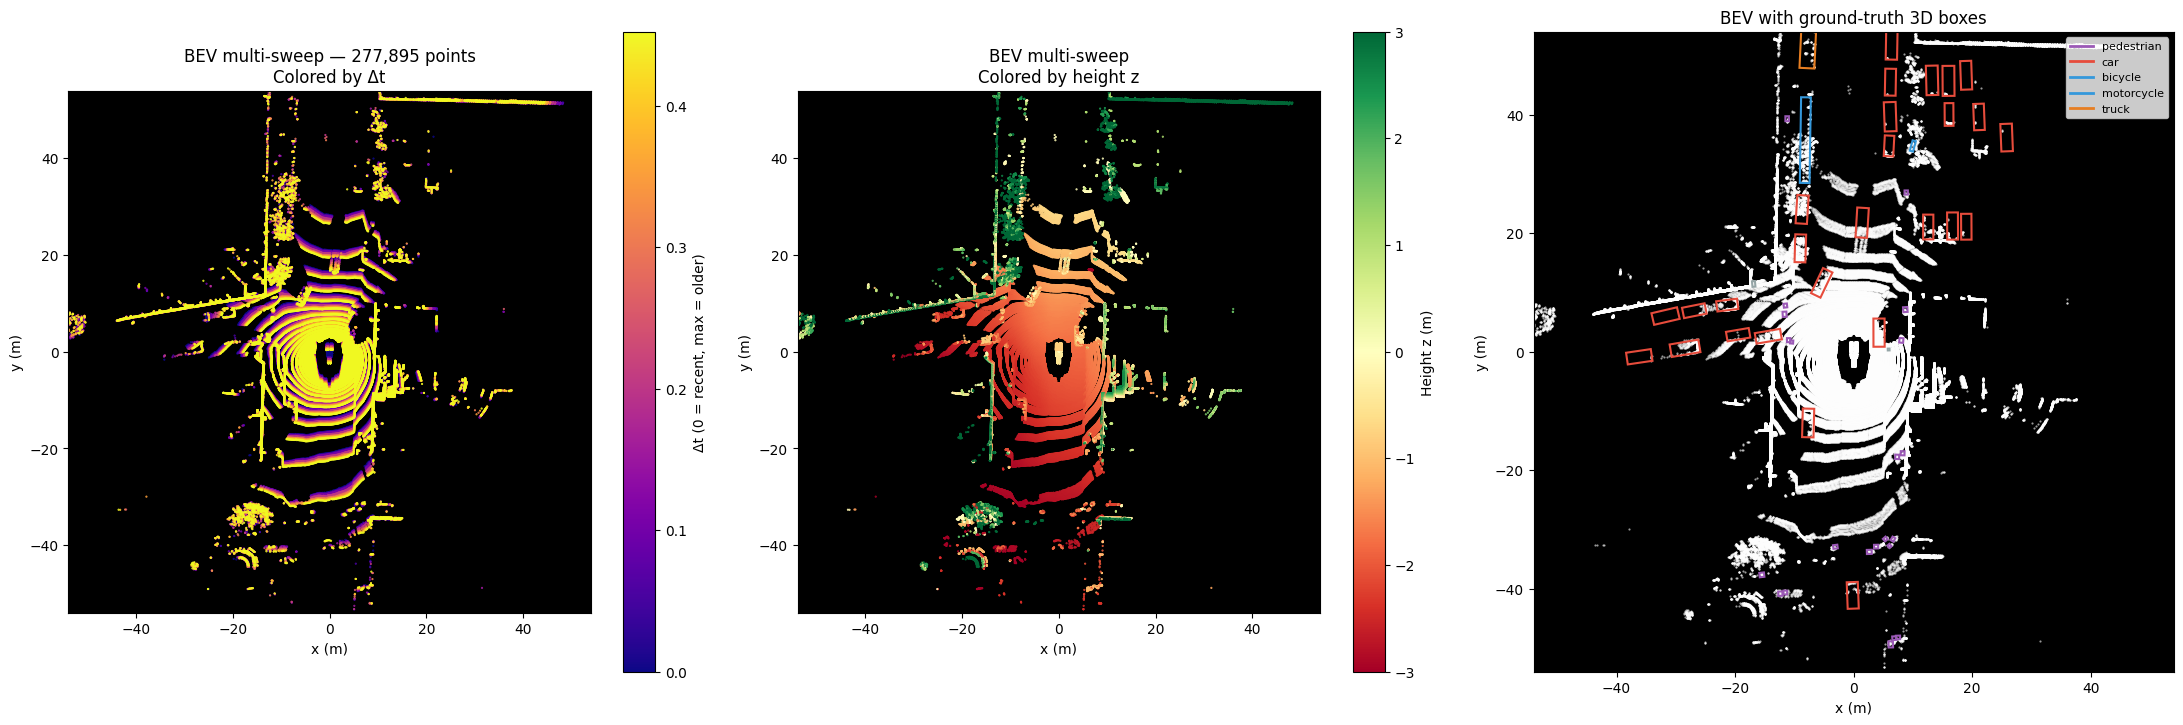

In [ ]:

# Helper function to extract Ground Truth annotations
def get_sample_boxes_in_lidar(nusc, sample):
    """
    Return all annotation boxes for a sample, transformed into the LiDAR sensor frame.
    """
    lidar_token = sample["data"]["LIDAR_TOP"]
    lidar_data = nusc.get("sample_data", lidar_token)

    cs = nusc.get("calibrated_sensor", lidar_data["calibrated_sensor_token"])
    ep = nusc.get("ego_pose", lidar_data["ego_pose_token"])

    boxes = []
    for ann_token in sample["anns"]:
        ann = nusc.get("sample_annotation", ann_token)

        box = Box(
            ann["translation"],
            ann["size"],
            Quaternion(ann["rotation"]),
            name=ann["category_name"]
        )

        # global → ego
        box.translate(-np.array(ep["translation"]))
        box.rotate(Quaternion(ep["rotation"]).inverse)

        # ego → sensor
        box.translate(-np.array(cs["translation"]))
        box.rotate(Quaternion(cs["rotation"]).inverse)

        boxes.append(box)

    return boxes


# Extract boxes
boxes = get_sample_boxes_in_lidar(nusc, sample)


# BEV visualization
fig, axes = plt.subplots(1, 3, figsize=(22, 7))


# --- 1 : colored by Δt ---
ax = axes[0]

dt = points[:, 4]

sc = ax.scatter(
    points[:, 0],
    points[:, 1],
    c=dt,
    s=0.3,
    cmap="plasma",
    vmin=0,
    vmax=dt.max(),
    rasterized=True
)

plt.colorbar(sc, ax=ax, label="Δt (0 = recent, max = older)")

ax.set_xlim(-54, 54)
ax.set_ylim(-54, 54)
ax.set_aspect("equal")

ax.set_title(f"BEV multi-sweep — {points.shape[0]:,} points\nColored by Δt")

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

ax.set_facecolor("black")
ax.grid(False)


# --- 2 : colored by height z ---
ax2 = axes[1]

z = points[:, 2]

sc2 = ax2.scatter(
    points[:, 0],
    points[:, 1],
    c=z,
    s=0.3,
    cmap="RdYlGn",
    vmin=-3,
    vmax=3,
    rasterized=True
)

plt.colorbar(sc2, ax=ax2, label="Height z (m)")

ax2.set_xlim(-54, 54)
ax2.set_ylim(-54, 54)
ax2.set_aspect("equal")

ax2.set_title("BEV multi-sweep\nColored by height z")

ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")

ax2.set_facecolor("black")
ax2.grid(False)


# --- 3 : point cloud + ground truth boxes ---
ax3 = axes[2]

ax3.scatter(points[:, 0], points[:, 1], s=0.3, c="white", alpha=0.6)

COLOR_MAP = {
    "car": "#e74c3c",
    "truck": "#e67e22",
    "bus": "#f1c40f",
    "trailer": "#f1c40f",
    "construction_vehicle": "#e67e22",
    "barrier": "#2ecc71",
    "motorcycle": "#3498db",
    "bicycle": "#3498db",
    "pedestrian": "#9b59b6",
    "traffic_cone": "#9b59b6",
}


legend_entries = {}

for box in boxes:


    cat = box.name.lower()

    cat_mapped = None
    for key in COLOR_MAP:
        if key in cat:
            cat_mapped = key
            break

    color = COLOR_MAP.get(cat_mapped, "#95a5a6")

    corners = box.bottom_corners()[:2, :]

    rect = plt.Polygon(
        corners.T,
        closed=True,
        fill=False,
        edgecolor=color,
        linewidth=1.5
    )

    ax3.add_patch(rect)

    if cat_mapped and cat_mapped not in legend_entries:
        legend_entries[cat_mapped] = color


handles = [
    Line2D([0], [0], color=c, lw=2, label=n)
    for n, c in legend_entries.items()
]

ax3.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.8)

ax3.set_xlim(-54, 54)
ax3.set_ylim(-54, 54)
ax3.set_aspect("equal")

ax3.set_title("BEV with ground-truth 3D boxes")

ax3.set_xlabel("x (m)")
ax3.set_ylabel("y (m)")

ax3.set_facecolor("black")
ax3.grid(False)


plt.tight_layout()
plt.show()

### **Temporal structure**

nuScenes provides sequences of LiDAR frames. The LiDAR sensor operates at approximately **20 Hz**, meaning a new point cloud is captured every **50 milliseconds**. 

This temporal structure allows models such as CenterPoint to estimate **object velocities** and perform **tracking across frames**.

The following animation shows consecutive LiDAR frames together with their ground-truth bounding boxes.

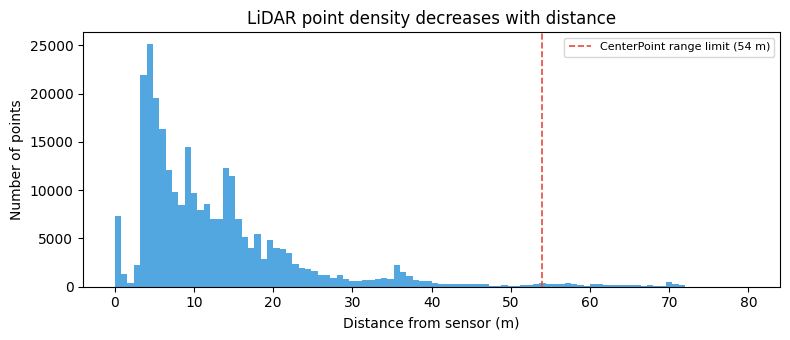

In [4]:
distances = np.linalg.norm(points[:, :2], axis=1)

fig, ax = plt.subplots(figsize=(8, 3.5))

ax.hist(
    distances,
    bins=100,
    range=(0, 80),
    color="#3498db",
    edgecolor="none",
    alpha=0.85
)

ax.set_xlabel("Distance from sensor (m)")
ax.set_ylabel("Number of points")

ax.set_title("LiDAR point density decreases with distance")

ax.axvline(
    x=54,
    color="#e74c3c",
    linestyle="--",
    linewidth=1.2,
    label="CenterPoint range limit (54 m)"
)

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## **2. Voxelization of the LiDAR Point Cloud**

### **Motivation**

A LiDAR sensor captures the environment as a **point cloud**: a set of points in 3D space. Unlike images, point clouds are **unordered and irregular**, there is no underlying grid structure and the number of points varies from frame to frame.

Convolutional neural networks, however, are designed to process **structured inputs arranged on regular grids**. To apply them to LiDAR data, the point cloud must first be converted into a structured spatial representation.

**Voxelization** is the standard solution: it discretizes the 3D space into small volumetric cells called **voxels**, producing a regular grid that CNNs can process.

---

### **Principle**

Voxelization divides the 3D space surrounding the ego vehicle into a regular grid. Each voxel is defined by a spatial resolution $(\Delta x, \Delta y, \Delta z)$. Each point $(x, y, z)$ is assigned to the voxel whose cell it falls into along each axis.

All points falling inside the same voxel are grouped together. In practice, only voxels that contain at least one point are stored, resulting in a **sparse representation** that avoids allocating memory for empty space.

---

### **Two variants in the CenterPoint paper**

The CenterPoint paper evaluates two voxelization strategies:

**VoxelNet-style (3D voxels)**  
The 3D space is discretized along all three spatial dimensions $(x, y, z)$. Each voxel aggregates the points it contains into a feature vector, processed by a **sparse 3D convolutional backbone** that preserves the full vertical geometry of the scene before projecting onto a BEV feature map.

**PointPillars-style (pillars)**  
The vertical dimension is collapsed: the space is discretized only along the ground plane $(x, y)$, and each cell corresponds to a vertical column called a **pillar**. This enables the use of **2D convolutional networks**, which are significantly faster but lose some vertical geometric information.

The paper shows that the VoxelNet variant achieves higher accuracy, while the PointPillars variant is faster. In this notebook we focus on the **VoxelNet formulation**.

---

### **CenterPoint implementation**

CenterPoint uses the following parameters for the VoxelNet variant:

| Parameter | Value | Description |
|---|---|---|
| Voxel size | [0.075, 0.075, 0.2] m | $(\Delta x, \Delta y, \Delta z)$ spatial resolution |
| Point cloud range | [−54, −54, −5, 54, 54, 3] m | Detection zone |
| Max points per voxel | 10 | If exceeded, points are randomly subsampled |
| Max voxels | 120 000 (test) | GPU memory cap |

Each point carries **5 features**: $(x, y, z, \text{intensity}, \Delta t)$. The $\Delta t$ feature encodes the temporal offset of the point relative to the current sweep, and is specific to the multi-sweep aggregation used by CenterPoint (10 sweeps).

Once points are grouped into voxels, only **94,598** voxels out of a theoretical grid of 
**1440 × 1440 × 40 = 82,944,000** are occupied, a sparsity of **0.114%**.

In [5]:
from det3d.ops.point_cloud.point_cloud_ops import points_to_voxel

VOXEL_SIZE = [0.075, 0.075, 0.2]
PC_RANGE   = [-54, -54, -5, 54, 54, 3]
MAX_POINTS = 10
MAX_VOXELS = 120000

voxels, coordinates, num_points_per_voxel = points_to_voxel(
    points, VOXEL_SIZE, PC_RANGE, MAX_POINTS,
    reverse_index=True, max_voxels=MAX_VOXELS
)

# Dimensions théoriques de la grille
grid_x = int((PC_RANGE[3] - PC_RANGE[0]) / VOXEL_SIZE[0])  # 1440
grid_y = int((PC_RANGE[4] - PC_RANGE[1]) / VOXEL_SIZE[1])  # 1440
grid_z = int((PC_RANGE[5] - PC_RANGE[2]) / VOXEL_SIZE[2])  # 40
total_voxels = grid_x * grid_y * grid_z

sparsity = voxels.shape[0] / total_voxels * 100

print(f"Output shapes:")
print(f"  voxels      : {voxels.shape}  → (N_voxels, max_points, 5 features)")
print(f"  coordinates : {coordinates.shape}  → (N_voxels, 3) indices (z, y, x)")
print(f"  num_points  : {num_points_per_voxel.shape}")
print()
print(f"Theoretical grid : {grid_x} × {grid_y} × {grid_z} = {total_voxels:,} voxels")
print(f"Occupied voxels  : {voxels.shape[0]:,} / {MAX_VOXELS:,}")
print(f"Sparsity         : {sparsity:.4f}% occupied  → extremely sparse")
print()
print(f"Points per voxel — min: {num_points_per_voxel.min()}  "
      f"max: {num_points_per_voxel.max()}  "
      f"mean: {num_points_per_voxel.mean():.2f}")


Output shapes:
  voxels      : (94598, 10, 5)  → (N_voxels, max_points, 5 features)
  coordinates : (94598, 3)  → (N_voxels, 3) indices (z, y, x)
  num_points  : (94598,)

Theoretical grid : 1440 × 1440 × 40 = 82,944,000 voxels
Occupied voxels  : 94,598 / 120,000
Sparsity         : 0.1141% occupied  → extremely sparse

Points per voxel — min: 1  max: 10  mean: 2.56


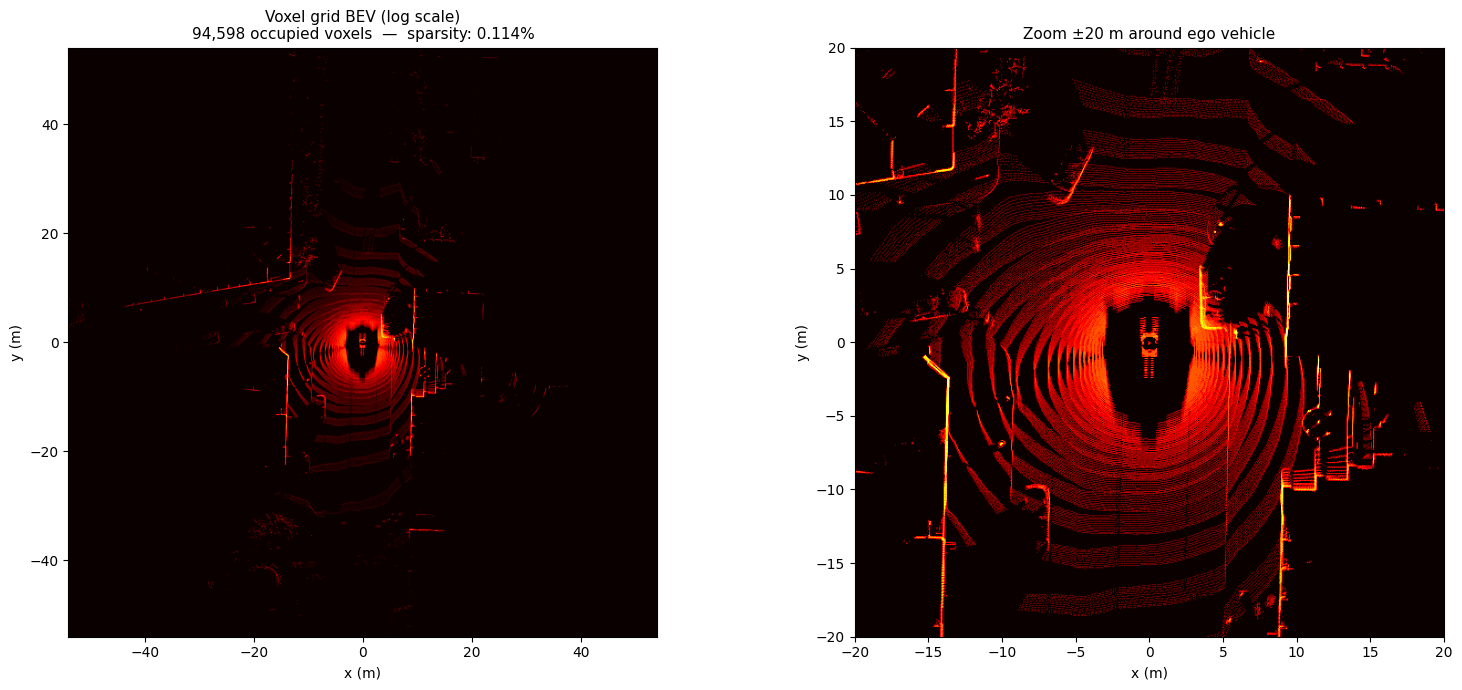

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Construire la grille BEV (projection selon z, somme des points)
bev_grid = np.zeros((grid_y, grid_x), dtype=np.float32)
for coord, npts in zip(coordinates, num_points_per_voxel):
    y_idx, x_idx = int(coord[1]), int(coord[2])
    if 0 <= y_idx < grid_y and 0 <= x_idx < grid_x:
        bev_grid[y_idx, x_idx] += npts

extent = [PC_RANGE[0], PC_RANGE[3], PC_RANGE[1], PC_RANGE[4]]

# Vue globale
ax = axes[0]
ax.imshow(np.log1p(bev_grid), cmap='hot', origin='lower', extent=extent, aspect='equal')
ax.set_title(f'Voxel grid BEV (log scale)\n{voxels.shape[0]:,} occupied voxels  —  sparsity: {sparsity:.3f}%',
             fontsize=11)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

# Zoom ±20 m autour du véhicule ego
ax2 = axes[1]
zoom_m = 20
cx, cy = grid_x // 2, grid_y // 2
zpx = int(zoom_m / VOXEL_SIZE[0])
sub = bev_grid[cy - zpx:cy + zpx, cx - zpx:cx + zpx]
ax2.imshow(np.log1p(sub), cmap='hot', origin='lower',
           extent=[-zoom_m, zoom_m, -zoom_m, zoom_m], aspect='equal')
ax2.set_title(f'Zoom ±{zoom_m} m around ego vehicle', fontsize=11)
ax2.set_xlabel('x (m)'); ax2.set_ylabel('y (m)')

plt.tight_layout()
plt.show()


The voxel grid reveals the characteristic structure of a LiDAR point cloud. The concentric 
ring patterns reflect the rotational scanning mechanism of the sensor: each ring corresponds 
to one full revolution, and the spacing between rings increases with distance as point density 
decreases.

The zoom around the ego vehicle confirms that fine geometric structures, walls, building 
facades, and parked vehicles are well preserved at the 7.5 cm resolution used by CenterPoint.

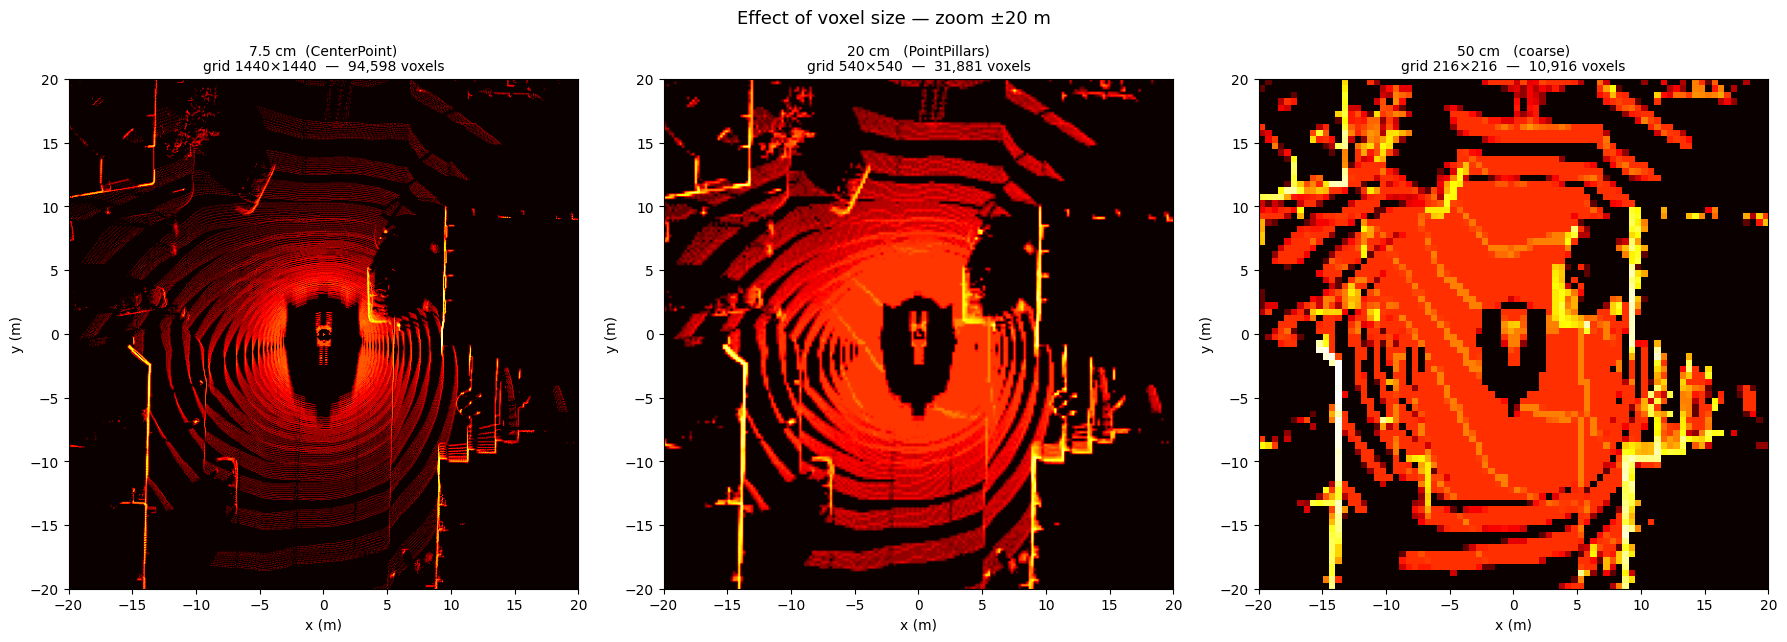

In [ ]:
SIZES = {
    '7.5 cm  (CenterPoint)': [0.075, 0.075, 0.2],
    '20 cm   (PointPillars)': [0.20,  0.20,  0.2],
    '50 cm   (coarse)':       [0.50,  0.50,  0.2],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, vs) in zip(axes, SIZES.items()):
    vox_i, coo_i, npts_i = points_to_voxel(
        points, vs, PC_RANGE, MAX_POINTS,
        reverse_index=True, max_voxels=MAX_VOXELS
    )

    gx = int((PC_RANGE[3] - PC_RANGE[0]) / vs[0])
    gy = int((PC_RANGE[4] - PC_RANGE[1]) / vs[1])
    grid_i = np.zeros((gy, gx), dtype=np.float32)
    for coord, npts in zip(coo_i, npts_i):
        yi, xi = int(coord[1]), int(coord[2])
        if 0 <= yi < gy and 0 <= xi < gx:
            grid_i[yi, xi] += npts

    # Zoom ±20 m
    zoom_m = 20
    cx_i, cy_i = gx // 2, gy // 2
    zpx_i = int(zoom_m / vs[0])
    sub_i = grid_i[cy_i - zpx_i:cy_i + zpx_i, cx_i - zpx_i:cx_i + zpx_i]

    ax.imshow(np.log1p(sub_i), cmap='hot', origin='lower',
              extent=[-zoom_m, zoom_m, -zoom_m, zoom_m], aspect='equal')
    ax.set_title(f'{label}\ngrid {gx}×{gy}  —  {vox_i.shape[0]:,} voxels', fontsize=10)
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

plt.suptitle('Effect of voxel size — zoom ±20 m', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



The three grids illustrate the resolution trade-off introduced by the voxel size parameter:

- **7.5 cm (CenterPoint default):** Individual scan rings remain distinct and fine geometric 
structures are preserved. A pedestrian or a narrow pole occupies several voxels, making it 
detectable.
- **20 cm (PointPillars default):** The geometry is still recognizable but scan rings begin 
to merge. Small objects start to blur into their surroundings. The grid is 7× smaller 
(540×540), which reduces memory and computation significantly.
- **50 cm (coarse):** Geometric detail is largely destroyed. Distinct structures fuse into 
large blocks. At this resolution, detecting small objects such as pedestrians or cyclists 
becomes unreliable.





### **Voxel Feature Encoding — MeanVFE**

After voxelization, each occupied voxel contains a variable number of points (between 1 and 
`max_points=10`), all padded to the same size with zeros. The backbone cannot work with this 
variable-length structure — it needs **exactly one feature vector per voxel**.

This is the role of the **Voxel Feature Extractor (VFE)**: aggregate the points inside each 
voxel into a single fixed-size vector.

CenterPoint uses the simplest possible aggregation: the **mean** of the features of all real 
points in the voxel (padding zeros are excluded using `num_points`):

$$f_{\text{voxel}} = \frac{1}{k} \sum_{i=1}^{k} p_i \quad \text{where } k \text{ is the actual number of points in the voxel}$$

This operation has **no learnable parameters** — it is a pure averaging step.

In [ ]:

voxel_tensor   = torch.tensor(voxels, dtype=torch.float32).to(DEVICE)
coords_tensor  = torch.tensor(coordinates, dtype=torch.int32).to(DEVICE)
num_pts_tensor = torch.tensor(num_points_per_voxel, dtype=torch.int32).to(DEVICE)

# Ajouter l'index de batch (batch_size=1)
batch_idx    = torch.zeros((coords_tensor.shape[0], 1), dtype=torch.int32, device=DEVICE)
batch_coords = torch.cat([batch_idx, coords_tensor], dim=1)  # (N_vox, 4)

with torch.no_grad():
    encoded = model.reader(voxel_tensor, num_pts_tensor, batch_coords)

print(f"Entrée  : {voxel_tensor.shape}  — (N_vox, max_points, 5)")
print(f"Sortie  : {encoded.shape}        — (N_vox, 5)")
print()

# Vérification manuelle sur 3 voxels
print("Vérification MeanVFE :")
print(f"{'Voxel':<8} {'k pts':<8} {'Moyenne manuelle':<45} {'Sortie reader':<45} {'OK'}")
print("-" * 120)
for idx in [0, 100, 1000]:
    k          = num_points_per_voxel[idx]
    manual     = voxels[idx, :k, :].mean(axis=0)
    from_model = encoded[idx].cpu().numpy()
    ok         = np.allclose(manual, from_model, atol=1e-4)
    print(f"{idx:<8} {k:<8} {str(np.round(manual, 4)):<45} {str(np.round(from_model, 4)):<45} {'✓' if ok else '✗'}")


Entrée  : torch.Size([94598, 10, 5])  — (N_vox, max_points, 5)
Sortie  : torch.Size([94598, 5])        — (N_vox, 5)

Vérification MeanVFE :
Voxel    k pts    Moyenne manuelle                              Sortie reader                                 OK
------------------------------------------------------------------------------------------------------------------------
0        10       [-3.2103 -0.1112 -1.9098  3.8     0.0504]     [-3.2103 -0.1112 -1.9098  3.8     0.0504]     ✓
100      1        [-9.7892  0.3212 -2.3349 11.      0.    ]     [-9.7892  0.3212 -2.3349 11.      0.    ]     ✓
1000     1        [-9.2026  3.4498 -2.111   6.      0.    ]     [-9.2026  3.4498 -2.111   6.      0.    ]     ✓


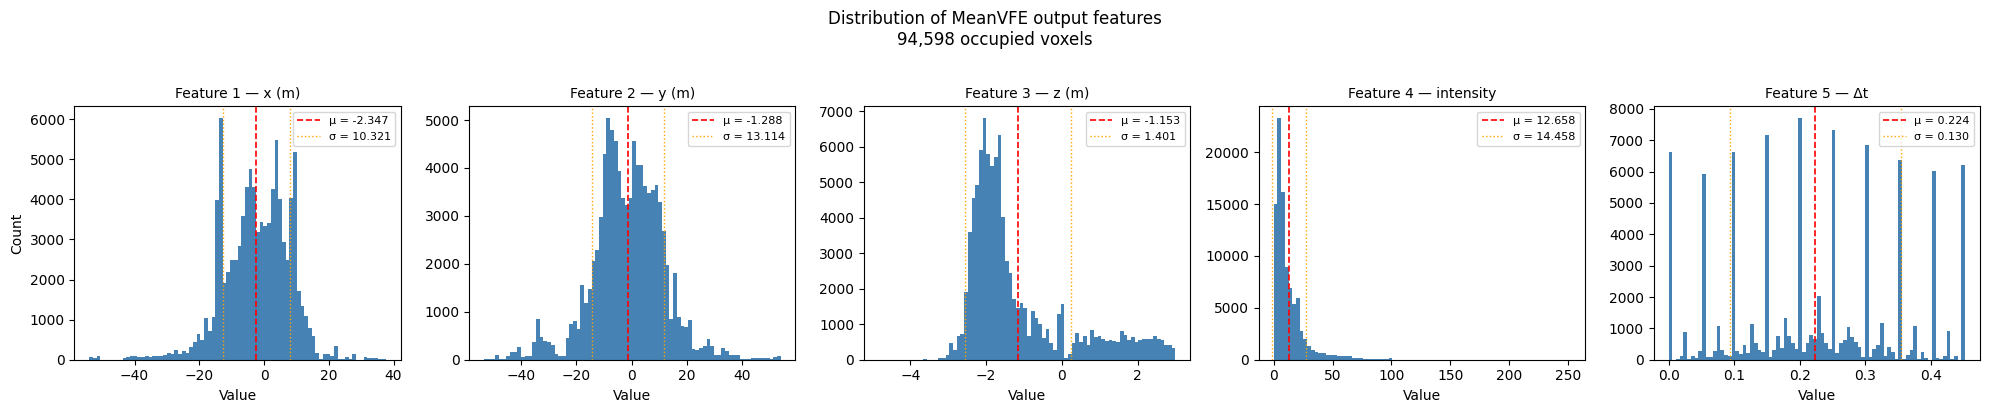

In [9]:
encoded_np = encoded.cpu().numpy()  # (N_vox, 5)
FEATURE_NAMES = ['x (m)', 'y (m)', 'z (m)', 'intensity', 'Δt']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (ax, fname) in enumerate(zip(axes, FEATURE_NAMES)):
    vals = encoded_np[:, i]
    ax.hist(vals, bins=80, color='steelblue', edgecolor='none')
    ax.axvline(vals.mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'μ = {vals.mean():.3f}')
    ax.axvline(vals.mean() - vals.std(), color='orange', linestyle=':', linewidth=1)
    ax.axvline(vals.mean() + vals.std(), color='orange', linestyle=':', linewidth=1,
               label=f'σ = {vals.std():.3f}')
    ax.set_title(f'Feature {i+1} — {fname}', fontsize=10)
    ax.set_xlabel('Value'); ax.set_ylabel('Count' if i == 0 else '')
    ax.legend(fontsize=8)

plt.suptitle(f'Distribution of MeanVFE output features\n'
             f'{encoded_np.shape[0]:,} occupied voxels', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


The verification confirms that the reader output is exactly the per-voxel mean of the raw 
point features, no transformation is applied.

The feature distributions reveal several properties of the encoded representation:

- **x** ($\mu = -2.35$ m, $\sigma = 10.32$ m) and **y** ($\mu = -1.29$ m, $\sigma = 13.11$ m) 
are slightly off-center, reflecting the actual position of the ego vehicle within the scene. 
Both features span the full detection range $[-54, 54]$ m, with higher density close to the 
ego vehicle where point coverage is denser.
- **z** ($\mu = -1.15$ m, $\sigma = 1.40$ m) shows two distinct peaks: one around $-2$ m 
corresponding to ground-level returns, and one around $-0.5$ m corresponding to vehicle 
rooftops. The distribution spans $[-4, 3]$ m, consistent with the configured detection 
range $[-5, 3]$ m.
- **intensity** ($\mu = 12.66$, $\sigma = 14.45$) is strongly right-skewed: most surfaces 
produce weak returns, while a small number of highly reflective surfaces such as road 
markings and traffic signs produce strong peaks near 255.
- **$\Delta t$** ($\mu = 0.225$, $\sigma = 0.130$) shows exactly 10 discrete peaks, one per 
aggregated sweep, each contributing a roughly equal number of voxels.

These 5-dimensional voxel features, together with their 3D coordinates, are passed as a 
sparse tensor to the backbone.

## **3. Sparse 3D Backbone and 2D Neck**

### **3D Backbone**

#### **Motivation**

After the MeanVFE, we have a set of ~94k voxel feature vectors positioned in a 3D grid of 
**1440 × 1440 × 40** cells. The backbone must process this 3D structure and produce a 
compact 2D representation that the detection head can work with.

A standard dense 3D CNN would need to process all 83 million cells of the grid, the vast 
majority of which are empty. CenterPoint instead uses a **sparse 3D convolutional network** 
that only computes on occupied voxels.


#### **Architecture**

The backbone progressively downsamples the 3D grid through 5 blocks while increasing the 
number of feature channels. At the end, the remaining depth dimension is collapsed to 
produce a dense BEV feature map.
```
Input : sparse (~94k voxels, 5 ch)  →  grid [40, 1440, 1440]
  ↓  Block 1 :   5 →  16 ch  →  grid [40, 1440, 1440]  (no downsampling)
  ↓  Block 2 :  16 →  32 ch  →  grid [20,  720,  720]  (stride 2)
  ↓  Block 3 :  32 →  64 ch  →  grid [10,  360,  360]  (stride 2)
  ↓  Block 4 :  64 → 128 ch  →  grid [ 5,  180,  180]  (stride 2)
  ↓  Block 5 : 128 → 128 ch  →  grid [ 2,  180,  180]  (stride 2 on z only)
  ↓  reshape  : 2 × 128 ch   →  256 ch
Output : (1, 256, 180, 180)  —  dense BEV feature map
```

Each downsampling step halves the resolution while doubling the number of feature channels.

The final step collapses the last 2 depth slices by **concatenating them along the channel 
dimension** — no geometric information is discarded, it is simply repackaged as additional 
channels. Each pixel in the output BEV feature map covers a **0.6 m × 0.6 m** area 
(108 m / 180 px).


In [10]:
# input_shape = (W, H, D) = (x_size, y_size, z_size)
input_shape = [1440, 1440, 40]

with torch.no_grad():
    bev_features, _ = model.backbone(encoded, batch_coords,
                                     batch_size=1, input_shape=input_shape)

print(f"Entrée  : sparse tensor  ({encoded.shape[0]:,} voxels, {encoded.shape[1]} ch)")
print(f"          grille 3D     : [40, 1440, 1440]")
print(f"Sortie  : {bev_features.shape}")
print(f"          résolution BEV : {108/180:.2f} m/pixel")
print(f"          couverture     : {int(180 * 108/180)} m × {int(180 * 108/180)} m")


Entrée  : sparse tensor  (94,598 voxels, 5 ch)
          grille 3D     : [40, 1440, 1440]
Sortie  : torch.Size([1, 256, 180, 180])
          résolution BEV : 0.60 m/pixel
          couverture     : 108 m × 108 m




### **2D Neck**

#### **Role**

The 2D neck takes the BEV feature map produced by the backbone **(1, 256, 180, 180)** and 
enriches it with **multi-scale context** before passing it to the detection head.

The backbone produces features at a single resolution (0.6 m/pixel). This is sufficient 
for large objects like trucks or buses, but small objects like pedestrians or cyclists 
require finer-scale context. The neck addresses this by processing the BEV map through 
several convolutional blocks at different strides and then **concatenating the upsampled 
results**.

The output is a richer feature map **(1, 512, 180, 180)** at the same spatial resolution 
but with twice as many channels, encoding both local fine-grained and global coarse-grained 
information.

In [11]:
with torch.no_grad():
    neck_features = model.neck(bev_features)

print(f"Entrée  : {bev_features.shape}")
print(f"Sortie  : {neck_features.shape}")
print(f"  → canaux : {bev_features.shape[1]} → {neck_features.shape[1]}")
print(f"  → résolution spatiale inchangée : {neck_features.shape[2]} × {neck_features.shape[3]}")


Entrée  : torch.Size([1, 256, 180, 180])
Sortie  : torch.Size([1, 512, 180, 180])
  → canaux : 256 → 512
  → résolution spatiale inchangée : 180 × 180


## **5. Detection Head — CenterHead**

### **5.1 From anchors to centers**

Previous 3D detectors (VoxelNet, PointPillars) rely on an **anchor-based**
strategy: a fixed set of candidate boxes of predefined sizes and orientations
is placed at every BEV location, and the network predicts residuals to fit
these anchors to real objects. This approach introduces an inherent bias that
penalizes heavily rotated objects and complicates positive/negative sample
assignment.

CenterPoint instead reformulates detection as a **keypoint estimation
problem**, following CenterNet [Zhou et al., 2019]: a point, unlike a box,
carries no intrinsic orientation, allowing the backbone to learn rotational
invariance more naturally. For each object class, the head predicts a
**heatmap** $\hat{Y} \in [0,1]^{W \times L \times K}$ where each spatial
location encodes the probability that an object center of that class lies at
that position in the BEV map.


### **5.2 Center heatmap**

During training, a 2D Gaussian peak is rendered at the projected ground-truth
center of each annotated object. The Gaussian radius is computed using the
**CornerNet radius function** [Law & Deng, 2018], which finds the largest
radius such that the rendered Gaussian still overlaps the ground-truth box by
at least a minimum IoU. The resulting radius is then clamped to a minimum of
$\tau = 2$ pixels, ensuring even small objects receive a sufficiently dense
supervision signal — important in BEV where object centers are much sparser
than in image-based detection.

The heatmap is trained with the **CornerNet focal loss**:

$$
\mathcal{L}_{\text{hm}} = -\frac{1}{N} \sum_{xyc}
\begin{cases}
(1 - \hat{Y}_{xyc})^{2}\,\log(\hat{Y}_{xyc}) & \text{if } Y_{xyc} = 1 \\
(1 - Y_{xyc})^{4}\,\hat{Y}_{xyc}^{2}\,\log(1 - \hat{Y}_{xyc}) & \text{otherwise}
\end{cases}
$$

The exponent 4 on the Gaussian envelope $(1-Y_{xyc})^4$ strongly
down-weights locations close to but not at the ground-truth center, while
the exponent 2 on $\hat{Y}_{xyc}^2$ down-weights easy negative predictions.
This is essential because only a tiny fraction of BEV locations correspond to
object centers: a standard cross-entropy loss would be dominated by
background pixels.

At inference, detections are extracted by applying a **score threshold** to
the heatmap, followed by **3D NMS** to remove duplicate predictions.

> **Attribution.** The Gaussian heatmap formulation, the CornerNet radius
> function, and the focal loss are taken from **CenterNet** (Zhou et al.,
> 2019). CenterPoint's contribution lies in applying this 2D center
> representation to 3D LiDAR detection and extending it with velocity
> prediction and two-stage refinement.


### **5.3 Task groups and regression heads**

CenterPoint groups the 10 nuScenes classes into **6 task groups**, each with
its own heatmap branch:

| Task | Classes | Heatmap channels |
|------|---------|-----------------|
| 1 | Car | 1 |
| 2 | Truck, Construction vehicle | 2 |
| 3 | Bus, Trailer | 2 |
| 4 | Barrier | 1 |
| 5 | Motorcycle, Bicycle | 2 |
| 6 | Pedestrian, Traffic cone | 2 |

For each detected center, parallel regression heads predict the remaining
box attributes:

| Head | Output | Description |
|------|--------|-------------|
| `reg` | $(o_x, o_y) \in \mathbb{R}^2$ | Sub-voxel offset — compensates voxelization quantization error |
| `height` | $h_g \in \mathbb{R}$ | Height above ground |
| `dim` | $(\log l,\, \log w,\, \log h) \in \mathbb{R}^3$ | Box size in log-space |
| `rot` | $(\sin\alpha,\, \cos\alpha) \in \mathbb{R}^2$ | Orientation — avoids $\pi$-periodicity discontinuity |
| `vel` | $(v_x,\, v_y) \in \mathbb{R}^2$ | Velocity (m/s) — see Section 5 |

All regression heads are supervised with an **L1 loss at ground-truth center
locations only** — background pixels contribute no regression gradient.


In [12]:
CLASS_NAMES = ['car','truck','construction_vehicle','bus','trailer',
               'barrier','motorcycle','bicycle','pedestrian','traffic_cone']



def draw_bev_box(ax, cx, cy, l, w, yaw, color, linestyle='-', lw=1.5, alpha=1.0):
    cos_y, sin_y = np.cos(yaw), np.sin(yaw)
    corners = np.array([[ l/2, w/2],[-l/2, w/2],[-l/2,-w/2],[ l/2,-w/2]])
    rot = np.array([[cos_y,-sin_y],[sin_y, cos_y]])
    c = (rot @ corners.T).T + np.array([cx, cy])
    xs = list(c[:,0]) + [c[0,0]]
    ys = list(c[:,1]) + [c[0,1]]
    ax.plot(xs, ys, color=color, linestyle=linestyle, linewidth=lw, alpha=alpha)


In [13]:

TASK_NAMES = [
    'Car',
    'Truck / Construction vehicle',
    'Bus / Trailer',
    'Barrier',
    'Motorcycle / Bicycle',
    'Pedestrian / Traffic cone'
]

raw_preds = {}
def hook_fn(module, input, output):
    raw_preds['output'] = output

hook = model.bbox_head.register_forward_hook(hook_fn)
with torch.no_grad():
    neck_out = model.neck(bev_features)
    _ = model.bbox_head(neck_out)
hook.remove()

task_list = raw_preds['output'][0]  # liste de 6 dicts

print(f"Nombre de tâches : {len(task_list)}")
print(f"Clés disponibles : {list(task_list[0].keys())}")
print()
for i, (task_name, pred) in enumerate(zip(TASK_NAMES, task_list)):
    print(f"Tâche {i+1} — {task_name}")
    for k, v in pred.items():
        print(f"  {k:8s}: {v.shape}")
    print()


Nombre de tâches : 6
Clés disponibles : ['reg', 'height', 'dim', 'rot', 'vel', 'hm']

Tâche 1 — Car
  reg     : torch.Size([1, 2, 180, 180])
  height  : torch.Size([1, 1, 180, 180])
  dim     : torch.Size([1, 3, 180, 180])
  rot     : torch.Size([1, 2, 180, 180])
  vel     : torch.Size([1, 2, 180, 180])
  hm      : torch.Size([1, 1, 180, 180])

Tâche 2 — Truck / Construction vehicle
  reg     : torch.Size([1, 2, 180, 180])
  height  : torch.Size([1, 1, 180, 180])
  dim     : torch.Size([1, 3, 180, 180])
  rot     : torch.Size([1, 2, 180, 180])
  vel     : torch.Size([1, 2, 180, 180])
  hm      : torch.Size([1, 2, 180, 180])

Tâche 3 — Bus / Trailer
  reg     : torch.Size([1, 2, 180, 180])
  height  : torch.Size([1, 1, 180, 180])
  dim     : torch.Size([1, 3, 180, 180])
  rot     : torch.Size([1, 2, 180, 180])
  vel     : torch.Size([1, 2, 180, 180])
  hm      : torch.Size([1, 2, 180, 180])

Tâche 4 — Barrier
  reg     : torch.Size([1, 2, 180, 180])
  height  : torch.Size([1, 1, 180, 18

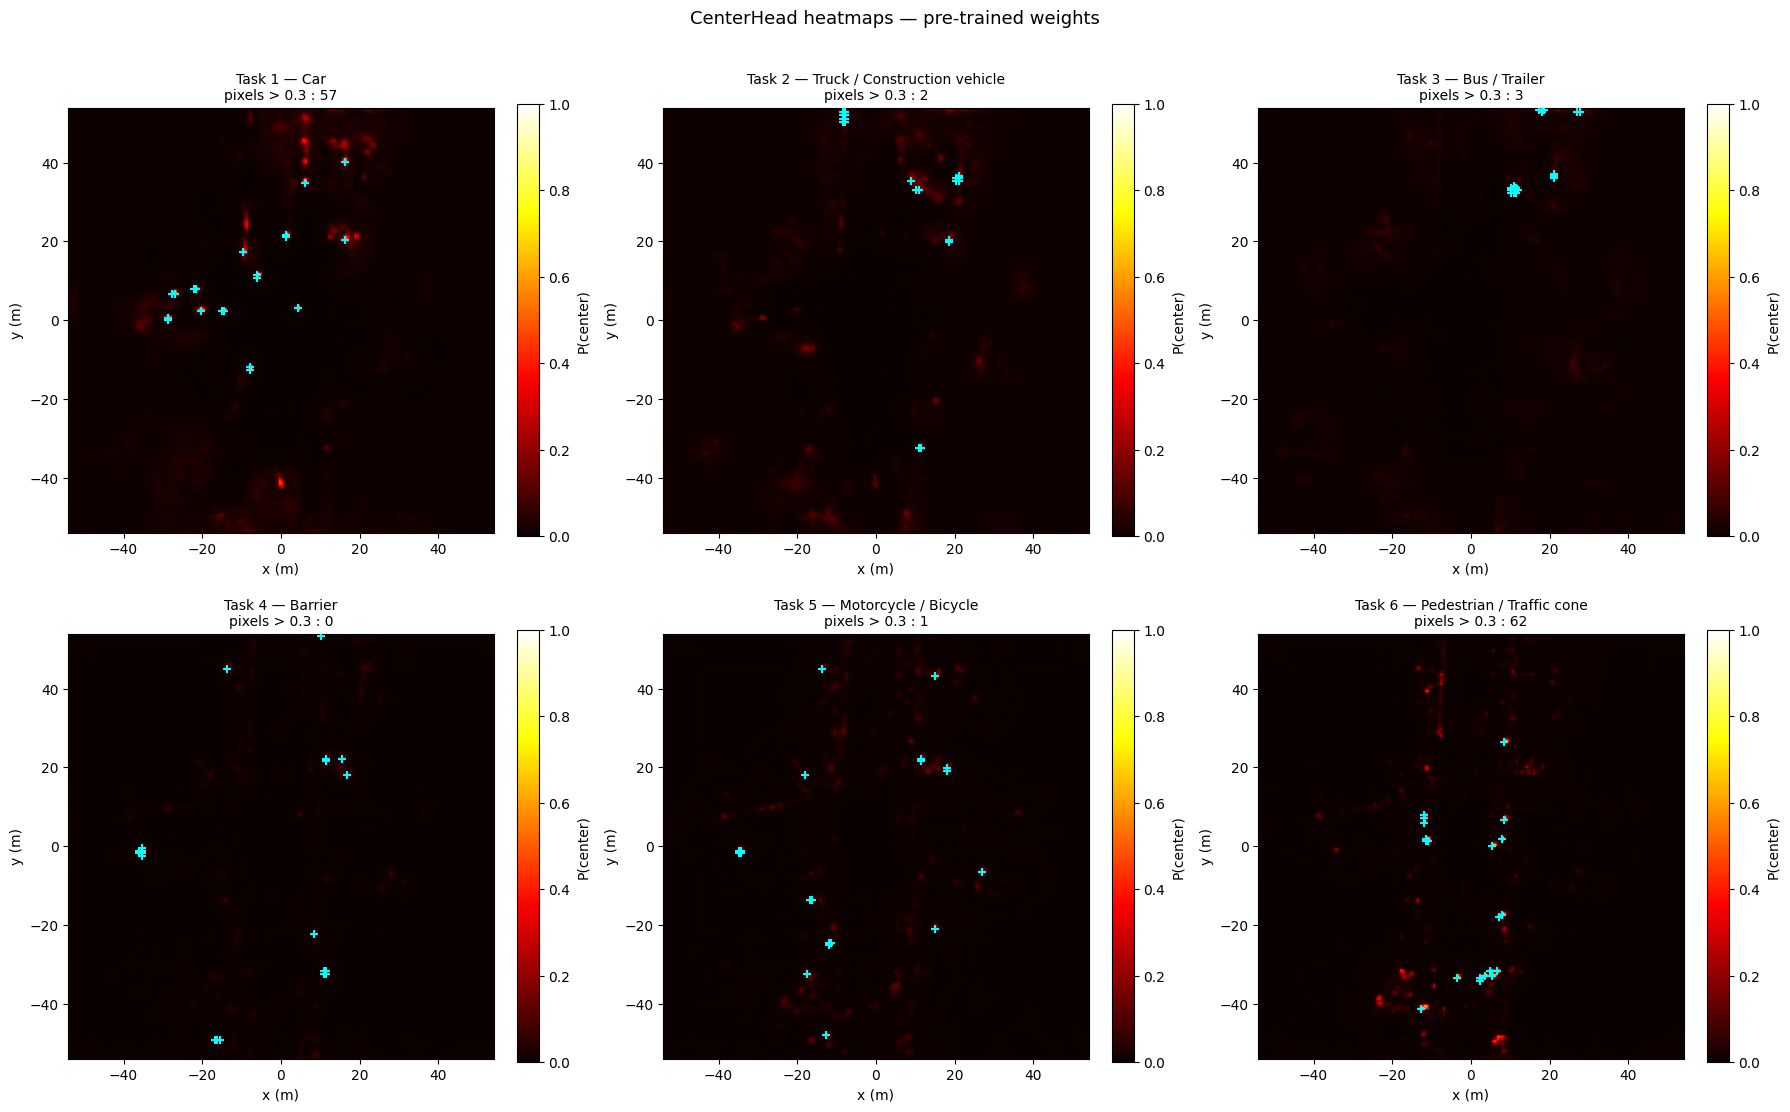

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (task_name, pred) in enumerate(zip(TASK_NAMES, task_list)):
    hm_prob = torch.sigmoid(pred['hm'])
    hm_max  = hm_prob[0].max(dim=0).values.cpu().numpy()

    ax = axes[i]
    im = ax.imshow(hm_max, vmin=0, vmax=1, cmap='hot',
                   origin='lower', extent=[-54, 54, -54, 54], aspect='equal')
    plt.colorbar(im, ax=ax, fraction=0.046, label='P(center)')

    flat_idx = np.argsort(hm_max.flatten())[::-1][:20]
    px_m = (flat_idx % 180) * (108/180) - 54
    py_m = (flat_idx // 180) * (108/180) - 54
    ax.scatter(px_m, py_m, s=40, c='cyan', marker='+', linewidths=1.5, zorder=5)

    n = int((hm_max > 0.3).sum())
    ax.set_title(f'Task {i+1} — {task_name}\npixels > 0.3 : {n}', fontsize=10)
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

plt.suptitle('CenterHead heatmaps — pre-trained weights', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [15]:
from det3d.torchie.parallel import collate_kitti

def to_device(x, dev):
    if isinstance(x, torch.Tensor): return x.to(dev)
    if isinstance(x, dict):  return {k: to_device(v, dev) for k, v in x.items()}
    if isinstance(x, list):  return [to_device(v, dev) for v in x]
    return x

batch = collate_kitti([val_dataset[sample_idx]])
batch = to_device(batch, DEVICE)  # défini plus tôt dans le notebook

with torch.no_grad():
    outputs = model(batch, return_loss=False)

boxes_np  = outputs[0]['box3d_lidar'].cpu().numpy()  # (N, 9): x,y,z,w,l,h,rot,vx,vy
scores_np = outputs[0]['scores'].cpu().numpy()
labels_np = outputs[0]['label_preds'].cpu().numpy()

print(f"Total détections : {len(boxes_np)}")
for cls_id in range(10):
    n = (labels_np == cls_id).sum()
    if n > 0:
        print(f"  {CLASS_NAMES[cls_id]:25s}: {n:3d}")


Total détections : 169
  car                      :  34
  truck                    :   5
  construction_vehicle     :  10
  trailer                  :   4
  barrier                  :   3
  motorcycle               :   8
  bicycle                  :  22
  pedestrian               :  65
  traffic_cone             :  18


GT boxes : 63


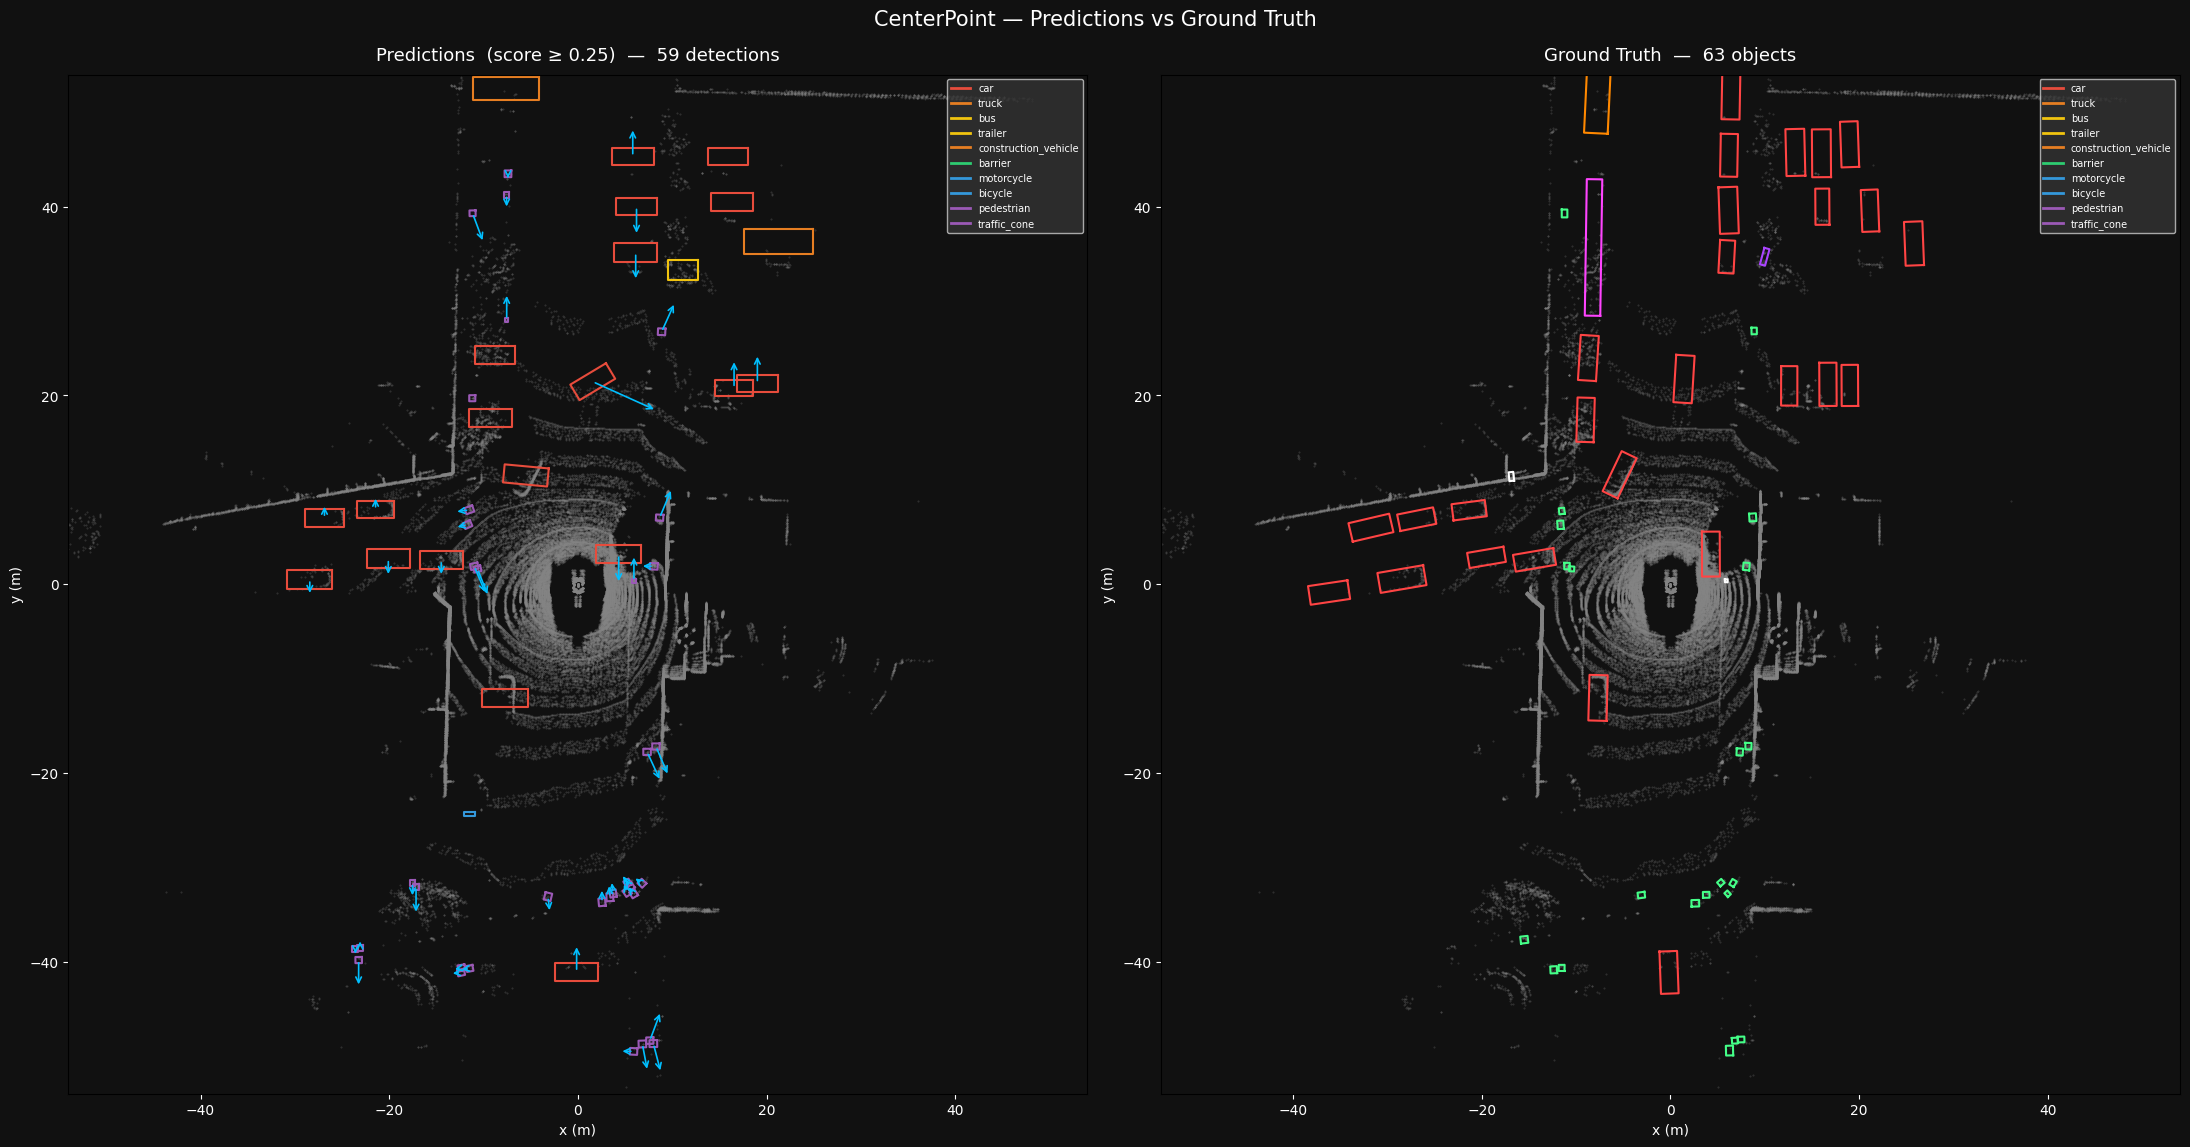

In [ ]:
SCORE_THR = 0.25

# Token et pose ego + calibration LiDAR
sample_token  = outputs[0]['metadata']['token']
nusc_sample   = nusc.get('sample', sample_token)
sd_record     = nusc.get('sample_data', nusc_sample['data']['LIDAR_TOP'])
cs_record     = nusc.get('calibrated_sensor', sd_record['calibrated_sensor_token'])
pose_record   = nusc.get('ego_pose', sd_record['ego_pose_token'])

# GT boxes : global → ego → LiDAR frame
gt_boxes_bev = []
for ann_token in nusc_sample['anns']:
    box = nusc.get_box(ann_token)
    # Global → ego
    box.translate(-np.array(pose_record['translation']))
    box.rotate(Quaternion(pose_record['rotation']).inverse)
    # Ego → LiDAR
    box.translate(-np.array(cs_record['translation']))
    box.rotate(Quaternion(cs_record['rotation']).inverse)
    cx, cy  = box.center[0], box.center[1]
    w, l, _ = box.wlh
    yaw     = box.orientation.yaw_pitch_roll[0]
    gt_boxes_bev.append((cx, cy, l, w, yaw, box.name))

print(f"GT boxes : {len(gt_boxes_bev)}")

# Visualisation
SCORE_THR = 0.25
fig, axes = plt.subplots(1, 2, figsize=(22, 11))
fig.patch.set_facecolor('#111111')

for ax in axes:
    ax.set_facecolor('#111111')
    ax.scatter(points[::4, 0], points[::4, 1], s=0.2,
               c='#888888', alpha=0.3, rasterized=True)
    ax.set_xlim(-54, 54); ax.set_ylim(-54, 54)
    ax.set_aspect('equal')
    ax.set_xlabel('x (m)', color='white')
    ax.set_ylabel('y (m)', color='white')
    ax.tick_params(colors='white')

# Gauche : prédictions
n_pred = 0
for box, score, label in zip(boxes_np, scores_np, labels_np):
    if score < SCORE_THR: continue
    cx, cy, w, l, yaw = box[0], box[1], box[3], box[4], box[6]
    vx, vy = box[7], box[8]
    color  = COLOR_MAP.get(CLASS_NAMES[int(label)], 'white')
    draw_bev_box(axes[0], cx, cy, l, w, yaw, color=color, lw=1.5)
    if np.sqrt(vx**2 + vy**2) > 0.5:
        axes[0].annotate('', xy=(cx+vx, cy+vy), xytext=(cx, cy),
                         arrowprops=dict(arrowstyle='->', color='deepskyblue', lw=1.2))
    n_pred += 1
axes[0].set_title(f'Predictions  (score ≥ {SCORE_THR})  —  {n_pred} detections',
                  fontsize=13, color='white', pad=10)



def get_gt_color(category):
    if 'car'            in category: return '#FF4444'
    if 'truck'          in category: return '#FF8800'
    if 'bus'            in category: return '#FFD700'
    if 'trailer'        in category: return '#CCFF00'
    if 'construction'   in category: return '#FFAA00'
    if 'barrier'        in category: return '#00CCFF'
    if 'motorcycle'     in category: return '#AA44FF'
    if 'bicycle'        in category: return '#FF44FF'
    if 'pedestrian'     in category: return '#44FF88'
    if 'traffic_cone'   in category: return '#FF8888'
    return 'white'

    
# Droite : ground truth
for cx, cy, l, w, yaw, category in gt_boxes_bev:
    color = get_gt_color(category)
    draw_bev_box(axes[1], cx, cy, l, w, yaw, color=color, lw=1.5)
axes[1].set_title(f'Ground Truth  —  {len(gt_boxes_bev)} objects',
                  fontsize=13, color='white', pad=10)

# Légende
legend_elems = [Line2D([0],[0], color=c, lw=2, label=n)
                for n, c in COLOR_MAP.items()]
for ax in axes:
    ax.legend(handles=legend_elems, loc='upper right', fontsize=7,
              facecolor='#333333', labelcolor='white', framealpha=0.8)

plt.suptitle('CenterPoint — Predictions vs Ground Truth', fontsize=15,
             color='white', y=1.01)
plt.tight_layout()
plt.show()


### **Interpretation**

The heatmaps confirm that the model produces strong, localized responses at
object positions. The Pedestrian / Traffic cone heatmap (Task 6) is the most
active (62 pixels > 0.3): small objects such as pedestrians and traffic cones
are numerous in nuScenes urban scenes, generating many spread-out low-to-
moderate confidence peaks. The Car heatmap (Task 1) follows with 57 pixels
> 0.3, reflecting fewer but sharper and higher-confidence peaks.

On sample_idx = 22, **169 raw detections** are produced before thresholding,
reduced to **59** after applying score ≥ 0.25. From the BEV comparison:

- **Cars and trucks** close to the ego vehicle are well localized and oriented
- **Velocity arrows** on moving vehicles point in coherent directions,
  estimated in a single forward pass without explicit tracking
- **Pedestrians and traffic cones** are largely filtered by the 0.25 threshold:
  65 pedestrian candidates are detected but most fall below the score cutoff,
  consistent with LiDAR sparsity on small objects
- **False positives** appear in dense, cluttered regions with no annotated objects

These observations are qualitative and specific to this single sample. The
model's published metrics (mAP = 56.0, NDS = 64.8, Table 6 of Yin et al.,
CVPR 2021) are computed over the full nuScenes validation set, see Section II.


## **4. Two-Stage Refinement — Manual Reconstruction**

The first stage of CenterPoint infers all box properties from a single
center-point feature, which may lack sufficient geometric information,
in practice, the LiDAR sensor typically observes the **side** of an object,
not its center (Yin et al., §4.1). The two-stage variant addresses this
with a lightweight second stage.

**No official two-stage configuration exists for nuScenes**, the paper
itself reports that two-stage refinement brings **no improvement on nuScenes**
(32-beam LiDAR, ~30k pts/frame, ≈ 1/6 of Waymo's density). We therefore
manually reconstruct the **feature extraction step** (steps 1–3 below) using
existing stage-1 outputs. No MLP inference is performed.

### **Mechanism (Yin et al., §4.1)**

1. For each stage-1 box, place **5 points** in the BEV plane: the predicted
   object center + the 4 outward-facing face centers. Top and bottom faces
   are excluded as they project to the same map-view location as the center.
2. Extract one feature vector per point via **bilinear interpolation** from
   the backbone map-view output $M$
3. Concatenate the 5 vectors and pass through an **MLP** (shared two-layer
   MLP with BN, ReLU, Dropout(0.3), then two branches of three FC layers)
4. The MLP produces two outputs:
   - A **class-agnostic confidence score** $\hat{I}_t$, trained with binary
     cross-entropy against an IoU-guided target:
     $$I_t = \min\!\bigl(1,\;\max(0,\;2 \times \text{IoU}_t - 0.5)\bigr)$$
   - A **box regression refinement** on top of stage-1 predictions (L1 loss)
5. Final confidence, geometric mean of both stages:
   $$\hat{Q}_t = \sqrt{\hat{Y}_t \cdot \hat{I}_t}$$

On Waymo (64-beam, ~180k pts/frame), this adds only **6–7 ms** per frame
and brings **+1.8–2.6 mAPH**. On nuScenes, the gain is negligible, the
sparser point cloud provides insufficient surface cues for the second stage
to improve upon stage-1 predictions.

The code below demonstrates steps 1–3.


In [17]:
import torch.nn.functional as F

# ── BEV feature map M 
# neck_features: (1, 512, 180, 180) already computed in Section 3
# BEV coverage: [-54, 54] m × [-54, 54] m  →  resolution = 108/180 = 0.6 m/pixel
PC_MIN = -54.0
PC_MAX  =  54.0

print('=== Stage-1 detections for sample_idx =', sample_idx, '===')
SCORE_THR = 0.25
mask_s1     = scores_np >= SCORE_THR
det_boxes   = boxes_np[mask_s1]   # (K, 9)  x,y,z,w,l,h,rot,vx,vy
det_scores  = scores_np[mask_s1]
det_labels  = labels_np[mask_s1]
K = len(det_boxes)
print(f'  Total detections (score ≥ {SCORE_THR}): {K}')
print(f'  Box array shape : {det_boxes.shape}  (x, y, z, w, l, h, rot, vx, vy)')

# ── Compute 5 surface-center points per box 
cx   = det_boxes[:, 0]           # x center (m)
cy   = det_boxes[:, 1]           # y center (m)
l    = det_boxes[:, 4]           # length along heading axis
w    = det_boxes[:, 3]           # width  (perpendicular)
yaw  = det_boxes[:, 6]           # heading angle (radians)

cos_y = np.cos(yaw);  sin_y = np.sin(yaw)

# Unit vector along heading:  (cos_y, sin_y)
# Unit vector perpendicular:  (-sin_y, cos_y)
pts_5 = np.stack([
    np.stack([cx,                    cy                   ], 1),  # center
    np.stack([cx + l/2 * cos_y,      cy + l/2 * sin_y    ], 1),  # front
    np.stack([cx - l/2 * cos_y,      cy - l/2 * sin_y    ], 1),  # back
    np.stack([cx + w/2 * (-sin_y),   cy + w/2 * cos_y    ], 1),  # left
    np.stack([cx - w/2 * (-sin_y),   cy - w/2 * cos_y    ], 1),  # right
], axis=1)  # (K, 5, 2)

print(f'\n=== 5 surface-center points ===')
print(f'  pts_5 shape : {pts_5.shape}  (K boxes, 5 points, 2 coords)')
print(f'  x range     : [{pts_5[..., 0].min():.1f}, {pts_5[..., 0].max():.1f}] m')
print(f'  y range     : [{pts_5[..., 1].min():.1f}, {pts_5[..., 1].max():.1f}] m')

# ── Bilinear interpolation from M (neck_features)
# grid_sample expects normalized coords in [-1, 1]
norm_x = (pts_5[..., 0] - PC_MIN) / (PC_MAX - PC_MIN) * 2 - 1  # (K, 5)
norm_y = (pts_5[..., 1] - PC_MIN) / (PC_MAX - PC_MIN) * 2 - 1

# Reshape to (1, K*5, 1, 2) as required by F.grid_sample
grid = torch.stack([
    torch.tensor(norm_x.reshape(-1), dtype=torch.float32),
    torch.tensor(norm_y.reshape(-1), dtype=torch.float32),
], dim=-1).unsqueeze(0).unsqueeze(2).to(DEVICE)  # (1, K*5, 1, 2)

with torch.no_grad():
    # neck_features: (1, 512, 180, 180)
    sampled = F.grid_sample(
        neck_features, grid,
        mode='bilinear', align_corners=True
    )  # (1, 512, K*5, 1)
    sampled = sampled.squeeze(0).squeeze(-1).T  # (K*5, 512)

C = neck_features.shape[1]  # 512

feat_per_box = sampled.reshape(K, 5 * C)  # (K, 5C = K, 2560)


print(f'\n=== BEV feature extraction ===')
print(f'  Feature map M         : {tuple(neck_features.shape)}  (N, C, H, W)')
print(f'  Sampled per point     : {tuple(sampled.shape)}  (K×5, C)')
print(f'  Per-box descriptor    : {tuple(feat_per_box.shape)}  (K, 5C = K, 5×{C})')
print(f'  → This (K, 5C) tensor would be the input to the stage-2 MLP')
print(f'  → The MLP outputs 1 IoU score per box → re-ranks detections')
print(f'\n  L2-norm of descriptors (mean ± std):')
norms = feat_per_box.norm(dim=1).cpu().numpy()
print(f'    {norms.mean():.2f} ± {norms.std():.2f}  (min {norms.min():.2f}, max {norms.max():.2f})')

=== Stage-1 detections for sample_idx = 22 ===
  Total detections (score ≥ 0.25): 59
  Box array shape : (59, 9)  (x, y, z, w, l, h, rot, vx, vy)

=== 5 surface-center points ===
  pts_5 shape : (59, 5, 2)  (K boxes, 5 points, 2 coords)
  x range     : [-30.8, 25.0] m
  y range     : [-49.9, 53.8] m

=== BEV feature extraction ===
  Feature map M         : (1, 512, 180, 180)  (N, C, H, W)
  Sampled per point     : (295, 512)  (K×5, C)
  Per-box descriptor    : (59, 2560)  (K, 5C = K, 5×512)
  → This (K, 5C) tensor would be the input to the stage-2 MLP
  → The MLP outputs 1 IoU score per box → re-ranks detections

  L2-norm of descriptors (mean ± std):
    10.31 ± 3.17  (min 5.88, max 18.04)


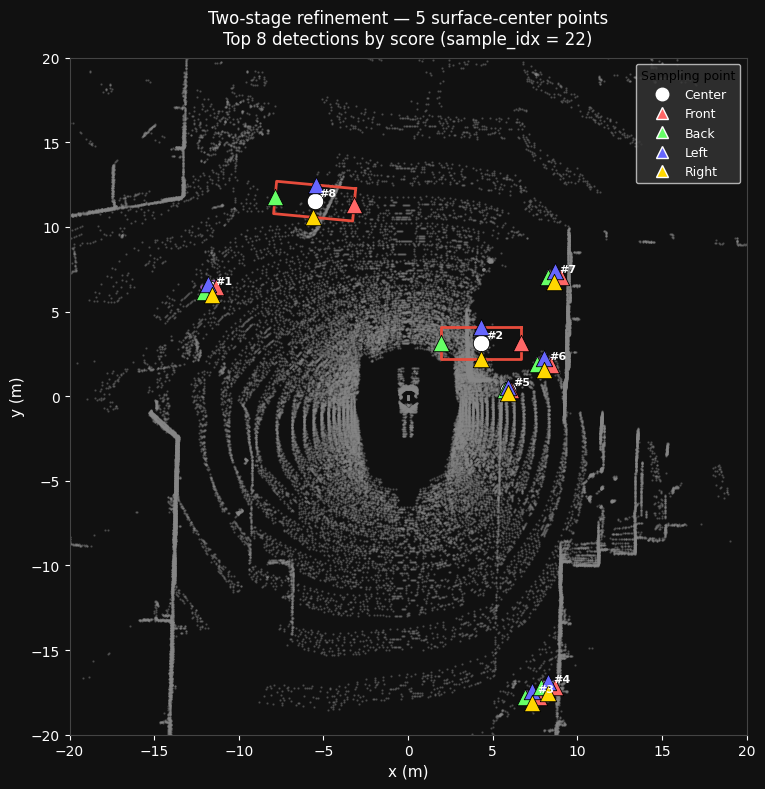

In [ ]:
# Visualization: 5 surface-center points on BEV 
TOP_N = 8
sort_idx   = np.argsort(det_scores)[::-1][:TOP_N]
top_boxes  = det_boxes[sort_idx]
top_pts    = pts_5[sort_idx]
top_labels = det_labels[sort_idx]

POINT_COLORS = ['white', '#FF6666', '#66FF66', '#6666FF', '#FFD700']
POINT_NAMES  = ['Center', 'Front', 'Back', 'Left', 'Right']

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor('#111111')
ax.set_facecolor('#111111')

ax.scatter(points[::5, 0], points[::5, 1],
           s=0.4, c='#888888', alpha=0.4, rasterized=True)

for rank, (box, pts, lbl) in enumerate(zip(top_boxes, top_pts, top_labels)):
    cx_b, cy_b, w_b, l_b, yaw_b = box[0], box[1], box[3], box[4], box[6]
    color = COLOR_MAP.get(CLASS_NAMES[int(lbl)], 'white')
    draw_bev_box(ax, cx_b, cy_b, l_b, w_b, yaw_b, color=color, lw=2.0)

    for p_idx, (px, py) in enumerate(pts):
        marker = 'o' if p_idx == 0 else '^'
        ax.scatter(px, py, s=140, c=POINT_COLORS[p_idx],
                   marker=marker, zorder=6, edgecolors='black', linewidths=0.6)

    ax.text(cx_b + 0.3, cy_b + 0.3, f'#{rank+1}',
            color='white', fontsize=8, zorder=7, fontweight='bold')

ax.set_xlim(-20, 20);  ax.set_ylim(-20, 20)
ax.set_aspect('equal')
ax.set_xlabel('x (m)', color='white', fontsize=11)
ax.set_ylabel('y (m)', color='white', fontsize=11)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#444')


legend_pts = [Line2D([0],[0], marker='o' if i==0 else '^', color='w',
                     markerfacecolor=POINT_COLORS[i], markersize=9,
                     label=POINT_NAMES[i], linestyle='None')
              for i in range(5)]
ax.legend(handles=legend_pts, loc='upper right', fontsize=9,
          facecolor='#333333', labelcolor='white', framealpha=0.85,
          title='Sampling point', title_fontsize=9)

ax.set_title(
    f'Two-stage refinement — 5 surface-center points\n'
    f'Top {TOP_N} detections by score (sample_idx = {sample_idx})',
    color='white', fontsize=12, pad=10
)
plt.tight_layout()

plt.show()


### **Interpretation**

For each of the **K = 59** stage-1 detections, 5 points are placed in the
BEV plane and projected into the **512-channel neck feature map**
(180 × 180 px, 0.6 m/pixel) via bilinear interpolation — giving K×5 = **295
sampled vectors** of dimension 512. Concatenating the 5 vectors per box
yields a **2 560-dimensional descriptor** per box: the exact input the
stage-2 MLP would receive.

The L2-norm of descriptors (mean **10.31 ± 3.17**, range 5.88–18.04)
reflects the activation level of the neck feature map at each sampling
location. High-norm descriptors correspond to points on LiDAR-rich surfaces;
low-norm ones fall on empty or occluded regions.

The visualization highlights a key design property of the 5-point sampling:

- For **large objects** (cars #2 and #8), the face-center points are clearly
  spread outside the box, probing distinct surface regions, the MLP
  receives rich geometric context about the full footprint
- For **small objects** (#1, #4–#7), the 5 points cluster nearly on top of
  each other since the BEV footprint is tiny, the descriptor is effectively
  a single-point feature repeated 5 times, which partly explains why the
  second stage brings no improvement on nuScenes where small objects dominate


**Figure caption.** Top-8 highest-confidence detections on sample_idx = 22.
The 5 sampling points are overlaid on the BEV point cloud:

- **White circle** — box center (heatmap peak position)
- **Red / green triangles** — front and back face centers (along heading axis)
- **Blue / gold triangles** — left and right face centers (perpendicular to heading)


## **5. Velocity Head and Greedy Tracking**

### **5.1 Velocity head**

**The problem.** CenterPoint detects objects frame by frame independently.
To track objects across time, we need to associate detections at frame $t$
with detections at frame $t-1$. But nuScenes annotates at 2 Hz, 0.5 s
between frames, meaning a pedestrian can move 1 m and a car 7 m between
two consecutive frames. Matching by position alone would miss most
associations.

**The solution.** The CenterHead includes a dedicated velocity branch that
predicts $(v_x, v_y)$ in m/s directly for each detected object, in the
ego-vehicle frame. It shares the same architecture as the other regression
heads (`reg`, `height`, `dim`, `rot`), a 3×3 conv branch on top of the
neck feature map, with two key differences:

- **It requires two input BEV feature maps**: the current and the previous
  time-step. The network learns to compare the two maps to estimate motion.
  On nuScenes, this is handled implicitly by the 10-sweep multi-sweep
  aggregation: each point carries its timestamp as a 5th feature, so
  moving objects leave elongated point trails that encode their velocity
  directly in the single-frame input.
- **Training target**: for each annotated object at frame $t$, the velocity
  target is $(x_t - x_{t-1}) / \Delta t$ in m/s, supervised with an
  **L1 loss at ground-truth center locations only**, exactly like all
  other regression heads.

At inference, each detection directly outputs $(v_x, v_y)$ with no
additional temporal computation.

### **5.2 Greedy tracking algorithm**

With a velocity estimate per detection, CenterPoint implements a remarkably
simple tracker (Yin et al., §4): instead of matching detections by raw
position, it first **projects each detection backward in time** using its
predicted velocity, then matches by closest projected position against the
tracks' last known positions.

**At each new LiDAR frame $t$, four steps:**

**Step 1 — Backward projection.**
For each new detection $i$ at frame $t$ with center $\hat{p}_i(t)$ and
predicted velocity $\hat{v}_i$, compute its estimated position at $t-1$:
$$\hat{p}_i(t \to t-1) = \hat{p}_i(t) - \hat{v}_i \cdot \Delta t \qquad (\Delta t = 0.5\,\text{s})$$
This projected position is then compared with each active track's last
known center $p_j(t-1)$.

*Example: a car detected at $(12, 5)$ with $v_x = 4$ m/s is projected back
to $(12 - 4 \times 0.5,\ 5) = (10, 5)$ — matching the track's last known
position at $t-1$.*

**Step 2 — Greedy matching.**
For each detection (in input order), find the nearest track by Euclidean
distance in the BEV plane. A match is accepted only if:
- distance $< \tau_c$ — **class-specific threshold** from `NUSCENE_CLS_VELOCITY_ERROR`:
  pedestrian = 1 m, bicycle/trailer = 3 m, car/truck = 4 m, bus = 5.5 m, motorcycle = 13 m
- **same class** — a car cannot match a pedestrian track
- the track has not already been matched in this frame

**Step 3 — Track update.**
- Matched detection → updates the track (new box, new velocity, age = 1)
- Unmatched detection → spawns a **new track** with a new ID
- Unmatched track → age += 1; center propagated forward with last known velocity

**Step 4 — Track deletion.**
Any track with age $\geq T = 3$ consecutive unmatched frames is deleted.

This tracker requires no Kalman filter, no appearance features, and runs
in **~1 ms** on top of detection — yet outperforms dedicated Kalman-filter
trackers by **+8.8 AMOTA** on nuScenes test set (Table 4 of the paper),
or **+3.7 AMOTA** with the same detector (Table 12), because the
learned velocity prediction is more accurate than a velocity estimated by
Kalman from noisy positions.


In [ ]:
sys.path.insert(0, '/home/r1/Analysis_of_CenterPoint/centerpoint/tools/nusc_tracking')
from pub_tracker import PubTracker, NUSCENES_TRACKING_NAMES

# Consecutive frames from same scene as sample_idx = 22 
info_22     = val_dataset._nusc_infos[sample_idx]
sample_22   = nusc.get('sample', info_22['token'])
scene       = nusc.get('scene', sample_22['scene_token'])

print(f'Scene: {scene["name"]}  ({scene["nbr_samples"]} samples total)')

scene_tokens = []
cur = nusc.get('sample', scene['first_sample_token'])
while True:
    scene_tokens.append(cur['token'])
    if cur['next'] == '': break
    cur = nusc.get('sample', cur['next'])

token_to_idx  = {val_dataset._nusc_infos[i]['token']: i for i in range(len(val_dataset))}
scene_indices = [token_to_idx[t] for t in scene_tokens if t in token_to_idx]
print(f'Tokens in scene: {len(scene_tokens)}')
print(f'Val-dataset indices in this scene: {scene_indices}')
print(f'sample_idx=22 position in scene: {scene_indices.index(sample_idx)}')

# ── Inference on each frame 

frame_dets = []
for fi, idx in enumerate(scene_indices):
    batch = collate_kitti([val_dataset[idx]])
    batch = to_device(batch, DEVICE)
    with torch.no_grad():
        out = model(batch, return_loss=False)
    boxes_i  = out[0]['box3d_lidar'].cpu().numpy()
    scores_i = out[0]['scores'].cpu().numpy()
    labels_i = out[0]['label_preds'].cpu().numpy()
    frame_dets.append({'boxes': boxes_i, 'scores': scores_i,
                       'labels': labels_i, 'token': out[0]['metadata']['token'],
                       'val_idx': idx})
    print(f'  Frame {fi:2d} (val_idx={idx:3d}) — '
          f'{(scores_i >= 0.25).sum():3d} dets (score≥0.25)')

print(f'\nInference done — {len(frame_dets)} frames')

# ── Official PubTracker (class-specific thresholds, as in the paper) 
# Classes tracked: car, truck, bus, trailer, pedestrian, motorcycle, bicycle
# NOT tracked: barrier, traffic_cone, construction_vehicle

DT            = 0.5    # nuScenes: 2 Hz → Δt = 0.5 s
SCORE_THR_TRK = 0.25
MAX_AGE       = 3      # T=3 from the paper

def format_for_tracker(boxes, scores, labels, score_thr):
    results = []
    for i in range(len(boxes)):
        if scores[i] < score_thr:
            continue
        cls_name = CLASS_NAMES[int(labels[i])]
        if cls_name not in NUSCENES_TRACKING_NAMES:
            continue
        results.append({
            'translation':     [float(boxes[i,0]), float(boxes[i,1]), float(boxes[i,2])],
            'velocity':        [float(boxes[i,7]), float(boxes[i,8])],
            'detection_name':  cls_name,
            'detection_score': float(scores[i]),
        })
    return results

tracker             = PubTracker(hungarian=False, max_age=MAX_AGE)
all_track_histories = {}   # tid → {label, history: [(t,x,y)]}
track_log           = []

for t, frame in enumerate(frame_dets):
    dets     = format_for_tracker(frame['boxes'], frame['scores'],
                                  frame['labels'], SCORE_THR_TRK)
    prev_id  = tracker.id_count
    tracks_t = tracker.step_centertrack(dets, time_lag=DT)
    n_new    = tracker.id_count - prev_id
    n_match  = len(dets) - n_new

    for tr in tracks_t:
        if tr['active'] == 0:
            continue
        tid  = tr['tracking_id']
        x, y = float(tr['ct'][0]), float(tr['ct'][1])
        if tid not in all_track_histories:
            all_track_histories[tid] = {'label': tr['label_preds'], 'history': []}
        all_track_histories[tid]['history'].append((t, x, y))

    track_log.append({'t': t, 'n_det': len(dets), 'n_match': n_match,
                      'n_new': n_new, 'n_active': len(tracks_t)})

print('Frame  Dets  Matched  New  Active')
for r in track_log:
    print(f'  {r["t"]:2d}    {r["n_det"]:3d}    {r["n_match"]:3d}     '
          f'{r["n_new"]:3d}    {r["n_active"]:3d}')
print(f'\nTotal track IDs assigned: {tracker.id_count}')
print(f'Active tracks at last frame: {len([tr for tr in tracks_t if tr["active"] > 0])}')


Scene: scene-0103  (40 samples total)
Tokens in scene: 40
Val-dataset indices in this scene: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
sample_idx=22 position in scene: 22


  Frame  0 (val_idx=  0) —  43 dets (score≥0.25)
  Frame  1 (val_idx=  1) —  56 dets (score≥0.25)
  Frame  2 (val_idx=  2) —  62 dets (score≥0.25)
  Frame  3 (val_idx=  3) —  79 dets (score≥0.25)
  Frame  4 (val_idx=  4) —  68 dets (score≥0.25)
  Frame  5 (val_idx=  5) —  71 dets (score≥0.25)
  Frame  6 (val_idx=  6) —  66 dets (score≥0.25)
  Frame  7 (val_idx=  7) —  65 dets (score≥0.25)
  Frame  8 (val_idx=  8) —  71 dets (score≥0.25)
  Frame  9 (val_idx=  9) —  74 dets (score≥0.25)
  Frame 10 (val_idx= 10) —  68 dets (score≥0.25)
  Frame 11 (val_idx= 11) —  65 dets (score≥0.25)
  Frame 12 (val_idx= 12) —  62 dets (score≥0.25)
  Frame 13 (val_idx= 13) —  58 dets (score≥0.25)
  Frame 14 (val_idx= 14) —  58 dets (score≥0.25)
  Frame 15 (val_idx= 15) —  59 dets (score≥0.25)
  Frame 16 (val_idx= 16) —  60 dets (score≥0.25)
  Frame 17 (val_idx= 17) —  61 dets (score≥0.25)
  Frame 18 (val_idx= 18) —  64 dets (score≥0.25)
  Frame 19 (val_idx= 19) —  54 dets (score≥0.25)
  Frame 20 (val_idx=

### **Interpretation — inference and tracking**

The table above shows the frame-by-frame state of the greedy tracker over
**scene-0103** (40 frames, 2 Hz → 20 s). `sample_idx = 22` is the 23rd
frame of this scene.

- **Dets**: detections with score ≥ 0.25 **and belonging to a tracked class**
  (barrier, traffic cone and construction vehicle are excluded from tracking)
  — between **40 and 74** per frame, averaging ~60
- **Matched**: detections associated to an existing track (within
  class-specific distance threshold, same class)
- **New**: unmatched detections spawning a new track
- **Active**: live tracks including those aged up to 3 frames

**Key observations:**

- **Frame 0:** 0 matches by construction — no prior tracks exist, all **40**
  detections spawn new tracks
- **Frames 1–12: low match rate** (4–21 out of 55–74 dets). The tracker
  hasn't yet built reliable history; velocity predictions from the first
  few frames may be inaccurate for just-appearing objects, causing
  backward-projected positions to exceed the class-specific threshold
- **Frames 15–28: match rate stabilizes** (24–39 matches) as the tracker
  accumulates history and velocity estimates improve for persistent tracks
- **Active tracks plateau around 110–180**, far above the ~60 dets/frame —
  this reflects tracks kept alive for up to 3 frames after their last match
- **1447 total track IDs** over 40 frames reveals that most detections
  create new tracks rather than continuing existing ones. This is expected
  for a distance-only, no-appearance tracker: fast-moving or briefly
  occluded objects whose velocity prediction exceeds the class threshold
  will fail to match and restart as a new track


Tracks with ≥ 3 observations: 147


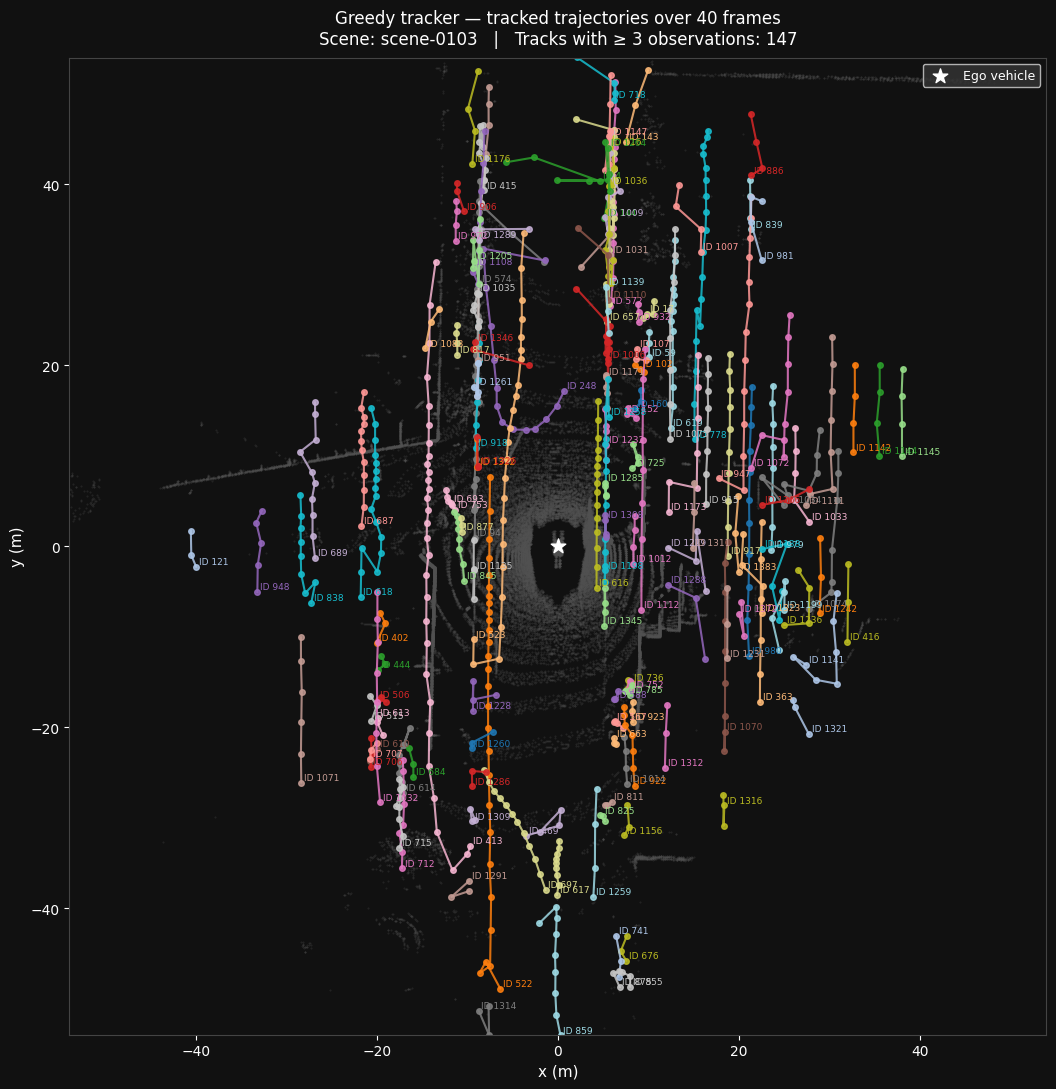

In [20]:
# ── Visualize tracked trajectories 
MIN_OBS = 3
long_tracks = {tid: tr for tid, tr in all_track_histories.items()
               if len(tr['history']) >= MIN_OBS}
print(f'Tracks with ≥ {MIN_OBS} observations: {len(long_tracks)}')

fig, ax = plt.subplots(figsize=(11, 11))
fig.patch.set_facecolor('#111111')
ax.set_facecolor('#111111')

ax.scatter(points[::5, 0], points[::5, 1],
           s=0.2, c='#555555', alpha=0.3, rasterized=True)

cmap = plt.get_cmap('tab20')
for k, (tid, tr) in enumerate(long_tracks.items()):
    hist  = tr['history']
    xs    = [h[1] for h in hist]
    ys    = [h[2] for h in hist]
    color = cmap(tid % 20)
    ax.plot(xs, ys, '-o', color=color, markersize=4, linewidth=1.5, alpha=0.85)
    ax.text(xs[-1]+0.3, ys[-1]+0.3, f'ID {tid}',
            color=color, fontsize=6.5, zorder=7)

ax.scatter([0], [0], s=120, c='white', marker='*', zorder=10, label='Ego vehicle')
ax.set_xlim(-54, 54); ax.set_ylim(-54, 54)
ax.set_aspect('equal')
ax.set_xlabel('x (m)', color='white', fontsize=11)
ax.set_ylabel('y (m)', color='white', fontsize=11)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#444')
ax.legend(loc='upper right', facecolor='#333333', labelcolor='white',
          framealpha=0.85, fontsize=9)
ax.set_title(
    f'Greedy tracker — tracked trajectories over {len(frame_dets)} frames\n'
    f'Scene: {scene["name"]}   |   Tracks with ≥ {MIN_OBS} observations: {len(long_tracks)}',
    color='white', fontsize=12, pad=10
)
plt.tight_layout()
plt.show()


**Figure caption.** Tracked trajectories over all 40 frames of scene-0103
(2 Hz, 20 s). Each colored polyline is a track with ≥ 3 observations
(**147** total). The white star marks the ego vehicle. Track IDs are
labeled at the last observed position.

**Observations:**

- Long vertical trajectories (along the y-axis) correspond to objects that
  remain in the scene for many frames at roughly constant velocity — the
  backward-projected position stays within the class-specific matching
  threshold
- Short tracks (< 3 obs, filtered out) are mostly false positives or objects
  entering/leaving the sensor range
- The tracker produces **no smoothing**: each node is a raw detection
  position — small jitter is visible. A Kalman filter would reduce this but
  was intentionally omitted from CenterPoint to keep the system simple
  and fast (~1 ms vs 73 ms for a Kalman-filter tracker, Table 12)
- **147 tracks with ≥ 3 observations** out of **1447** total track IDs
  confirms that the vast majority of track IDs are short-lived (1–2 frames),
  consistent with the low match rate observed in the tracking table


# **II. Experiments**

In the previous sections, we dissected each component of the CenterPoint pipeline on individual
frames. This section now takes a broader view:

- **Results from the original paper** — we review the official benchmarks reported by the authors
  on nuScenes to establish a reference baseline
- **Our inference results** — we run the pretrained model on the nuScenes mini validation split
  and analyze performance in detail, at both the global and per-class level
- **Additional experimentation** — we probe a specific design choice of the model to gain
  further insight into its behavior


## **1. Setup and Evaluation Metrics**

### **Evaluation metrics**

nuScenes defines two aggregate metrics and five localization error scores.

**Mean Average Precision (mAP)**
For each class, AP is computed by varying the score threshold and using **BEV center distance**
(rather than 3D IoU) as the matching criterion, averaged over four thresholds: 0.5 m, 1 m, 2 m, 4 m.
mAP is the mean AP across all 10 classes.

**nuScenes Detection Score (NDS)**
A composite metric combining mAP with five True Positive error metrics:

$$\text{NDS} = \frac{1}{10} \left[ 5 \cdot \text{mAP} + \sum_{e \in \mathcal{E}} (1 - \min(1, e)) \right]$$

with $\mathcal{E} = \{\text{ATE, ASE, AOE, AVE, AAE}\}$:

| Error | Full name | Definition |
|-------|-----------|------------|
| **ATE** | Average Translation Error | L2 center distance in BEV — x, y only (m) |
| **ASE** | Average Scale Error | $1 - \text{IoU}_{3D}$ on dimensions |
| **AOE** | Average Orientation Error | Smallest yaw angle difference (rad) |
| **AVE** | Average Velocity Error | L2 error on 2D velocity (m/s) |
| **AAE** | Average Attribute Error | $1 - \text{acc}$ on attributes (e.g. moving/stopped) |

These errors are computed on **true positives only** — a model must both detect and precisely
localize an object to contribute to NDS.

### **Experimental setup**

| Parameter | Value |
|-----------|-------|
| **Model** | CenterPoint-VoxelNet |
| **Backbone** | VoxelNet, voxel size 0.075 m × 0.075 m × 0.2 m, BEV grid 1440 × 1440 |
| **Checkpoint** | `epoch_20.pth` (pretrained, authors' weights) |
| **Dataset** | nuScenes mini — `val` split (2 scenes, ~80 keyframes) |
| **Sweeps** | 10 aggregated LiDAR sweeps |
| **Evaluation** | Official nuScenes devkit (`nuscenes-devkit`) |


## **2. Results from the Original Paper**

### **Best single model — nuScenes test set (Table 2)**

The strongest result reported uses CenterPoint-Voxel with a 0.075 m × 0.075 m grid and two
deformable convolution layers added in the detection head (test submission only):

| Model | mAP (%) | NDS (%) | PKL ↓ |
|-------|---------|---------|-------|
| CBGS (2019 challenge winner) | 52.8 | 63.3 | 0.77 |
| **CenterPoint-Voxel (paper)** | **58.0** | **65.5** | **0.69** |

CenterPoint outperforms the previous state-of-the-art by **+5.2 mAP** and **+2.2 NDS**.

### **Per-class AP on the test set (Table 13)**

| Car | Truck | Bus | Trailer | Constr. Veh. | Pedestrian | Motorcycle | Bicycle | Traffic Cone | Barrier |
|-----|-------|-----|---------|--------------|------------|------------|---------|--------------|---------|
| 84.6 | 51.0 | 60.2 | 53.2 | 17.5 | 83.4 | 53.7 | 28.7 | 76.7 | 70.9 |

Large, common objects (car, pedestrian) are detected very reliably. Small or rare objects
(construction vehicle, bicycle) remain challenging despite the center-based formulation.

Note: these per-class results use the test-set submission config (with additional deformable convolution layers), which achieves 58.0 mAP vs 56.4 mAP for the standard val config we replicate.




## **3. Our Inference Results**

We run the same pretrained CenterPoint-VoxelNet model on the **nuScenes mini validation set**
using `tools/test.py`. The overall results are:

| Model | Split | mAP (%) | NDS (%) |
|-------|-------|---------|---------|
| CenterPoint-VoxelNet (paper, Table 6) | nuScenes full val | 56.4 | 64.8 |
| CenterPoint-VoxelNet (our run)        | nuScenes mini val | **55.4** | **57.2** |

The **mAP is nearly identical** (−1.0 pt), confirming the pretrained weights reproduce the
detection quality faithfully.

The **NDS gap (−7.6 pts)** is expected: the mini val contains only **2 scenes** (~80 frames)
vs ~150 scenes in the full val. Rare classes (trailer, barrier, construction_vehicle) are nearly
absent — their TP errors default to 1.0, which strongly penalizes NDS.

The per-class analysis below gives a more detailed picture of the model's behavior on our subset.


In [ ]:
import json


# Load metrics
with open("../work_dirs/test/metrics_summary.json") as f:
    metrics = json.load(f)

CLASSES = ['car', 'truck', 'bus', 'trailer', 'construction_vehicle',
           'pedestrian', 'motorcycle', 'bicycle', 'traffic_cone', 'barrier']
DIST_THS = [0.5, 1.0, 2.0, 4.0]

mean_ap   = metrics['mean_ap']
nds       = metrics['nd_score']
mean_aps  = metrics['mean_dist_aps']
label_aps = metrics['label_aps']
tp_errors = metrics['label_tp_errors']

print(f"{'='*40}")
print(f"  mAP  : {mean_ap*100:.1f}%")
print(f"  NDS  : {nds*100:.1f}%")
print(f"{'='*40}")


  mAP  : 55.4%
  NDS  : 57.2%


### **Per-class Detection and Localization Quality**

The heatmap on the left shows the AP of each class at the four nuScenes distance thresholds.
A tight threshold (0.5 m) requires precise localization; a loose threshold (4 m) validates
any detection in the right neighborhood.

The heatmap on the right shows the five TP localization errors for correctly detected objects.
All values are lower-is-better; N/A means the metric is unavailable for that class on this split.


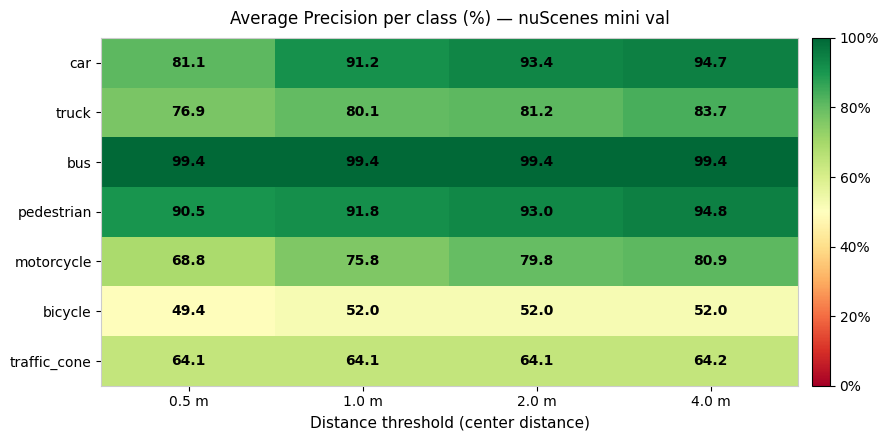

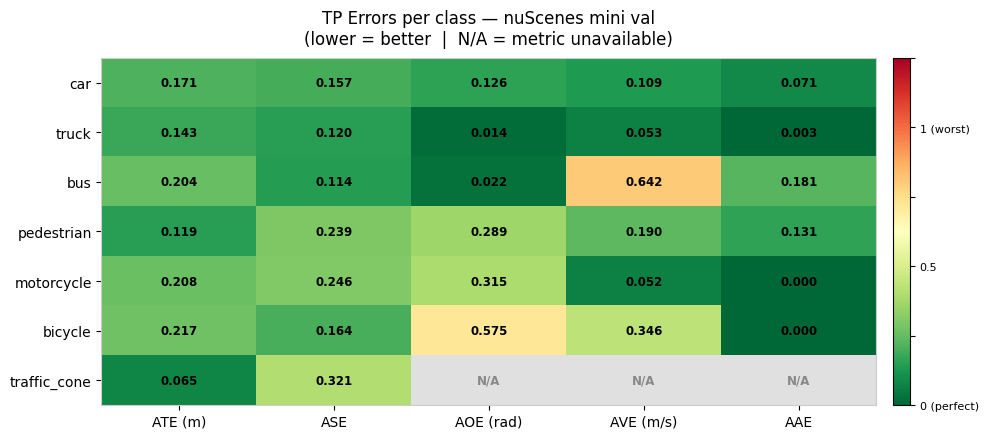

In [22]:
# AP heatmap: class × distance threshold (classes détectées uniquement)
CLASSES_DETECTED = [cls for cls in CLASSES if max(label_aps[cls][str(th)] for th in DIST_THS) > 0]

ap_matrix = np.array([
    [label_aps[cls][str(th)] for th in DIST_THS]
    for cls in CLASSES_DETECTED
])

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

masked = np.ma.masked_where(ap_matrix == 0.0, ap_matrix)
cmap = plt.cm.RdYlGn.copy()
cmap.set_bad(color='#e0e0e0')

im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=1, aspect='auto')

for i, cls in enumerate(CLASSES_DETECTED):
    for j, th in enumerate(DIST_THS):
        val = ap_matrix[i, j]
        label = f"{val*100:.1f}" if val > 0 else "—"
        ax.text(j, i, label, ha='center', va='center',
                color='black', fontsize=10, fontweight='bold')

ax.set_xticks(range(4))
ax.set_xticklabels([f"{th} m" for th in DIST_THS], color='black', fontsize=10)
ax.set_yticks(range(len(CLASSES_DETECTED)))
ax.set_yticklabels(CLASSES_DETECTED, color='black', fontsize=10)
ax.set_xlabel("Distance threshold (center distance)", color='black', fontsize=11)
ax.set_title("Average Precision per class (%) — nuScenes mini val", color='black', fontsize=12, pad=10)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.ax.yaxis.set_tick_params(color='black')
cbar.ax.set_yticklabels([f"{int(v*100)}%" for v in cbar.get_ticks()], color='black')
plt.setp(cbar.ax.spines.values(), color='black')

for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')
ax.tick_params(colors='black')

plt.tight_layout()
plt.show()

# TP errors heatmap (classes détectées uniquement)
ERROR_KEYS   = ['trans_err', 'scale_err', 'orient_err', 'vel_err', 'attr_err']
ERROR_LABELS = ['ATE (m)', 'ASE', 'AOE (rad)', 'AVE (m/s)', 'AAE']

tp_matrix = np.full((len(CLASSES_DETECTED), len(ERROR_KEYS)), np.nan)
for i, cls in enumerate(CLASSES_DETECTED):
    for j, key in enumerate(ERROR_KEYS):
        val = tp_errors[cls][key]
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            tp_matrix[i, j] = val

tp_clipped = np.clip(tp_matrix, 0, 1)
masked_tp  = np.ma.masked_invalid(tp_clipped)

fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

cmap_r = plt.cm.RdYlGn_r.copy()
cmap_r.set_bad(color='#e0e0e0')

im2 = ax.imshow(masked_tp, cmap=cmap_r, vmin=0, vmax=1, aspect='auto')

for i, cls in enumerate(CLASSES_DETECTED):
    for j, key in enumerate(ERROR_KEYS):
        raw_val = tp_errors[cls][key]
        if raw_val is None or (isinstance(raw_val, float) and np.isnan(raw_val)):
            label, tc = "N/A", '#888888'
        elif tp_clipped[i, j] >= 0.99:
            label, tc = "—", '#888888'
        else:
            label = f"{raw_val:.3f}"
            tc = 'black'
        ax.text(j, i, label, ha='center', va='center',
                color=tc, fontsize=8.5, fontweight='bold')

ax.set_xticks(range(len(ERROR_KEYS)))
ax.set_xticklabels(ERROR_LABELS, color='black', fontsize=10)
ax.set_yticks(range(len(CLASSES_DETECTED)))
ax.set_yticklabels(CLASSES_DETECTED, color='black', fontsize=10)
ax.set_title("TP Errors per class — nuScenes mini val\n(lower = better  |  N/A = metric unavailable)",
             color='black', fontsize=12, pad=10)

cbar2 = plt.colorbar(im2, ax=ax, fraction=0.03, pad=0.02)
cbar2.ax.yaxis.set_tick_params(color='black')
cbar2.ax.set_yticklabels(['0 (perfect)', '', '0.5', '', '1 (worst)'], color='black', fontsize=8)
plt.setp(cbar2.ax.spines.values(), color='black')

for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')
ax.tick_params(colors='black')

plt.tight_layout()
plt.show()


### **Discussion**

**Well-detected classes**

- **Bus (99.4% AP)**: perfect score at all four thresholds, including the tight 0.5 m one. This is
  likely an artifact of the mini split — very few bus instances appear in the 2 validation scenes,
  and all of them are correctly detected. This reflects a small sample rather than general robustness.
- **Pedestrian (92.5% AP)** and **Car (90.1% AP)**: dominant classes in the dataset — the model
  has clearly learned their distinctive LiDAR signatures.
- **Truck (80.5% AP)**: good detection despite high shape variability between truck subtypes.

**Notable localization errors**

- **Bicycle — AOE = 0.575 rad (~33°)**: hardest class to orient. Bicycles are nearly symmetric
  in LiDAR (thin tube shape) and move slowly, making yaw estimation highly ambiguous.
- **Pedestrian — AOE = 0.289 rad**: same symmetry issue — a standing person has no dominant
  orientation axis in the point cloud, so the model struggles to assign a reliable yaw angle.
- **Bus — AVE = 0.642 m/s**: highest velocity error. Buses stop and start frequently; the model
  sometimes predicts near-zero velocity for a bus that is about to move.
- **Bicycle — AVE = 0.346 m/s**: bicycles are slow and their motion is hard to estimate reliably
  from two consecutive sweeps.
- **Truck — AOE = 0.014 rad**: best orientation score in the table. Trucks are elongated and
  asymmetric — their principal axis is unambiguous in BEV.
- **Traffic cone — ATE = 0.065 m**: best translation score. Cones have a sharp, point-like LiDAR
  signature that is easy to localize precisely in BEV, despite their small size.
- **Traffic cone — ASE = 0.321**: high scale error. With very few LiDAR points per cone, the
  model struggles to estimate the 3D bounding box dimensions accurately.

**Comparison with the paper**

The gap of ~1 pt in mAP and ~7 pts in NDS between our run (mini val) and the paper (full val,
Table 6) is entirely attributable to the split size difference: 2 scenes versus ~150 in the full
val set. On well-represented classes, our results are consistent with the paper's figures,
confirming that the pretrained checkpoint is correctly loaded and evaluated.


## **4. Additional experimentation**

# **III. Critical Discussion**

### **Strengths**

#### **Simplified and principled detection formulation**

Replacing anchor boxes with a heatmap peak per object eliminates the need to enumerate orientation hypotheses and removes IoU-based anchor assignment from the training loop. This simplifies the learning problem and allows the backbone to internalize rotational invariance directly.  

The paper's ablation studies confirm that this representation change alone, with identical backbones and training, accounts for a consistent **3.8–4.3 mAPH improvement on Waymo** and **3.8–4.1 mAP on nuScenes** across both VoxelNet and PointPillars encoders  [oai_citation:0‡2006.11275v2.pdf](sediment://file_00000000e1e872468733c04a912e9c0f).

#### **Modular and efficient architecture**

The detection head operates on the BEV feature map and is backbone-agnostic, making it straightforward to combine with different 3D encoders.  

The two-stage refinement adds less than **10% computational overhead (~7 ms)** while delivering approximately **+2 mAP gain on Waymo**, and is substantially faster than prior two-stage methods based on volumetric feature extraction.

#### **Unified detection and tracking**

Integrating velocity prediction into the detection head reduces tracking to a nearest-neighbor matching step (~1 ms), requiring no separate motion model.  

Despite its simplicity, this approach outperforms the Kalman-filter-based tracker of Chiu et al. by **+3.7 AMOTA on nuScenes validation**, while being approximately **73× faster** for the tracking step alone.

---

### **Limitations**

#### **BEV representation and height ambiguity**

Collapsing the vertical dimension into feature channels discards information about object elevation.  

The height-above-ground head predicts a single $z$ value per center, which is incorrect when two objects at different heights project to the same BEV location (e.g., a pedestrian below a bridge or overlapping objects in multi-level structures).  

This limitation is shared by all BEV-based detectors and is not specific to CenterPoint, but it represents a fundamental constraint of the representation.

#### **Center localization sensitivity and occlusion**

Detection relies on a clear heatmap peak at the geometric center of each object.  

As noted in the paper:  
> "the sensor often only sees the side of the object, but not its center."

Partial occlusions, truncation at the sensor boundary, or sparse point returns can suppress the center peak, causing the first stage to miss the object entirely.  

The two-stage refinement can improve localization once a center is found, but cannot recover a missed detection.

#### **Greedy tracking and identity switches**

The tracking algorithm matches detections to tracks greedily by spatial proximity after velocity-based displacement.  

This strategy has no re-identification capability. If two objects cross paths (e.g., pedestrians), the tracker is likely to swap their identities, producing an **ID switch**.  

In dense scenarios, a more robust assignment strategy (e.g., Hungarian algorithm with appearance features) would be preferable.

#### **Two-stage gain is sensor-dependent**

The second stage provides measurable improvement only when LiDAR point density is sufficient:

- **Waymo (64-beam, ~180k points/frame):** ~+2 mAP  
- **nuScenes (32-beam, ~30k points/frame):** negligible gain  

This highlights a practical limitation: performance depends strongly on sensor quality.  

Similarly, small objects (e.g., pedestrians with PointPillars) may occupy only **1 × 1 voxel** in the BEV grid, severely limiting what the second stage can learn from their surface features.